# Community detection in complex networks

Basics:
* Communities are **locally dense connected subgraphs** in a network.
* Community detection aims to uncover the inherent community structure of a network.

Definitions:
* Clique - a fully connected subgraph within a larger graph.
* Strong community - each node has more edges connecting it to other nodes inside the group than to nodes outside the group.
* Weak community - the total internal degree of the group exceeds its total external degree.

Approaches and algorithms:
* Graph partitioning
* Hierarchical clustering (Girvan–Newman)
* Modularity optimization (Louvain)

## Introduction to community detection

Lets start with a simple example of a small graph.

In [44]:
import networkx as nx
import numpy as np

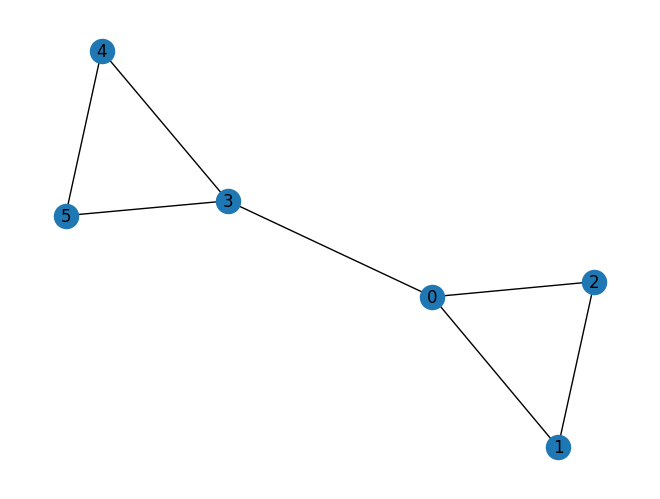

In [3]:
G = nx.Graph()
nx.add_cycle(G, [0, 1, 2])
nx.add_cycle(G, [3, 4, 5])
G.add_edge(0, 3)

nx.draw(G, with_labels=True)

How can we devide this graph into communities to get partitions of good quality? At first we'll do it by hand and validate if the partition is valid.

In [4]:
partition = [
    {0, 1, 2},
    {3, 4, 5},
]

nx.community.is_partition(G, partition)

True

Now, create a mapping between nodes and partitions, that will be of use for visualization and assesment of partition quality.

In [5]:
def create_node_to_partition_mapping(partition):
  node_to_partition = {}
  for idx, cluster_nodes in enumerate(partition):
      for node in cluster_nodes:
          node_to_partition[node] = idx
  return node_to_partition

node_to_partition = create_node_to_partition_mapping(partition)
node_to_partition

{0: 0, 1: 0, 2: 0, 3: 1, 4: 1, 5: 1}

Then visualize this simple graph again with color of nodes corresponding to the partition they belong to.

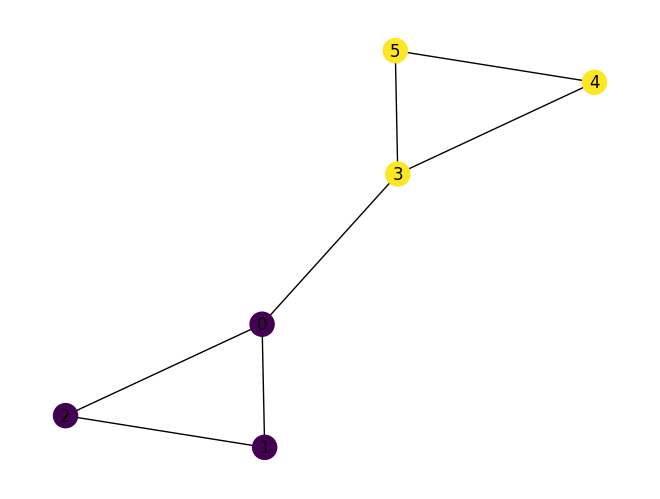

In [6]:
colors = [node_to_partition[n] for n in G.nodes]
nx.draw(G, node_color=colors, with_labels=True)

## Modularity

Now with the defined partition, we need to look for an answer to the question of can we evaluate the goodness of this network partition, and in a broader context, any partition of any graph?

One possible answer is to compare the connection density of the groups to a random baseline, as random networks do not have groups.

The modularity measure is defined as the difference between the number of internal links in the clusters and the expected number of links in a random network.

$$Q = \frac{1}{L}\sum_C(L_C - \frac{k_C^2}{4L})$$

where:
- $L$ - total number of links
- $L_c$ - number of links inside cluster $C$
- $\frac{k_C^2}{4L}$ - number of links in a random network

NetworkX comes with an efficient implementation of modularity calculation ```nx.community.quality.modularity(G, partition)```, that we will use to measure partition quality.

In [7]:
nx.community.quality.modularity(G, partition)

0.35714285714285715

We can verify how the modularity value change if we decide to change the partition.

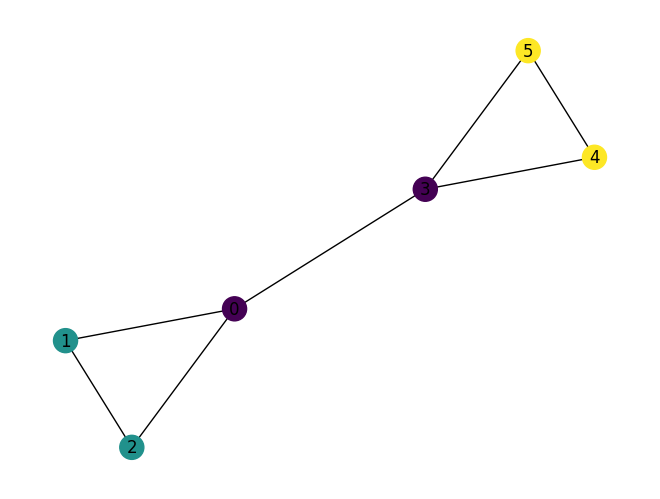

In [8]:
partition2 = [
    {0, 3},
    {1, 2},
    {4, 5},
]

colors = [create_node_to_partition_mapping(partition2)[n] for n in G.nodes]
nx.draw(G, node_color=colors, with_labels=True)

In [9]:
nx.community.quality.modularity(G, partition2)

0.0816326530612245

## Setting up networks for study

In the next sections of this notebook, we will be working with different networks, both artificial and real-world and algorithms that will help us identify communities within those networks.

In [10]:
connected_caveman_graph = nx.connected_caveman_graph(4, 8)
small_world_network = nx.watts_strogatz_graph(34, 4, 0.15)
windmill_graph = nx.windmill_graph(5, 7)
gaussian_random_partition_graph = nx.gaussian_random_partition_graph(n=34, s=9, v=9, p_in=0.7, p_out=0.03, seed=42)
random_partition_graph = nx.random_partition_graph([10, 8, 5, 5, 3, 3], 0.8, 0.04, seed=42)
karate_club_network = nx.karate_club_graph()

### Task 1
The first task is to take a look at the networks that are going to be the subject of study. Prepare a visualization of the graphs defined in the previous cell. Place all of them on a single plot, remember to include subplot titles to be able to identify them and find the best positionig that helps to reveale the network structure.

#### Code

In [11]:
import matplotlib.pyplot as plt

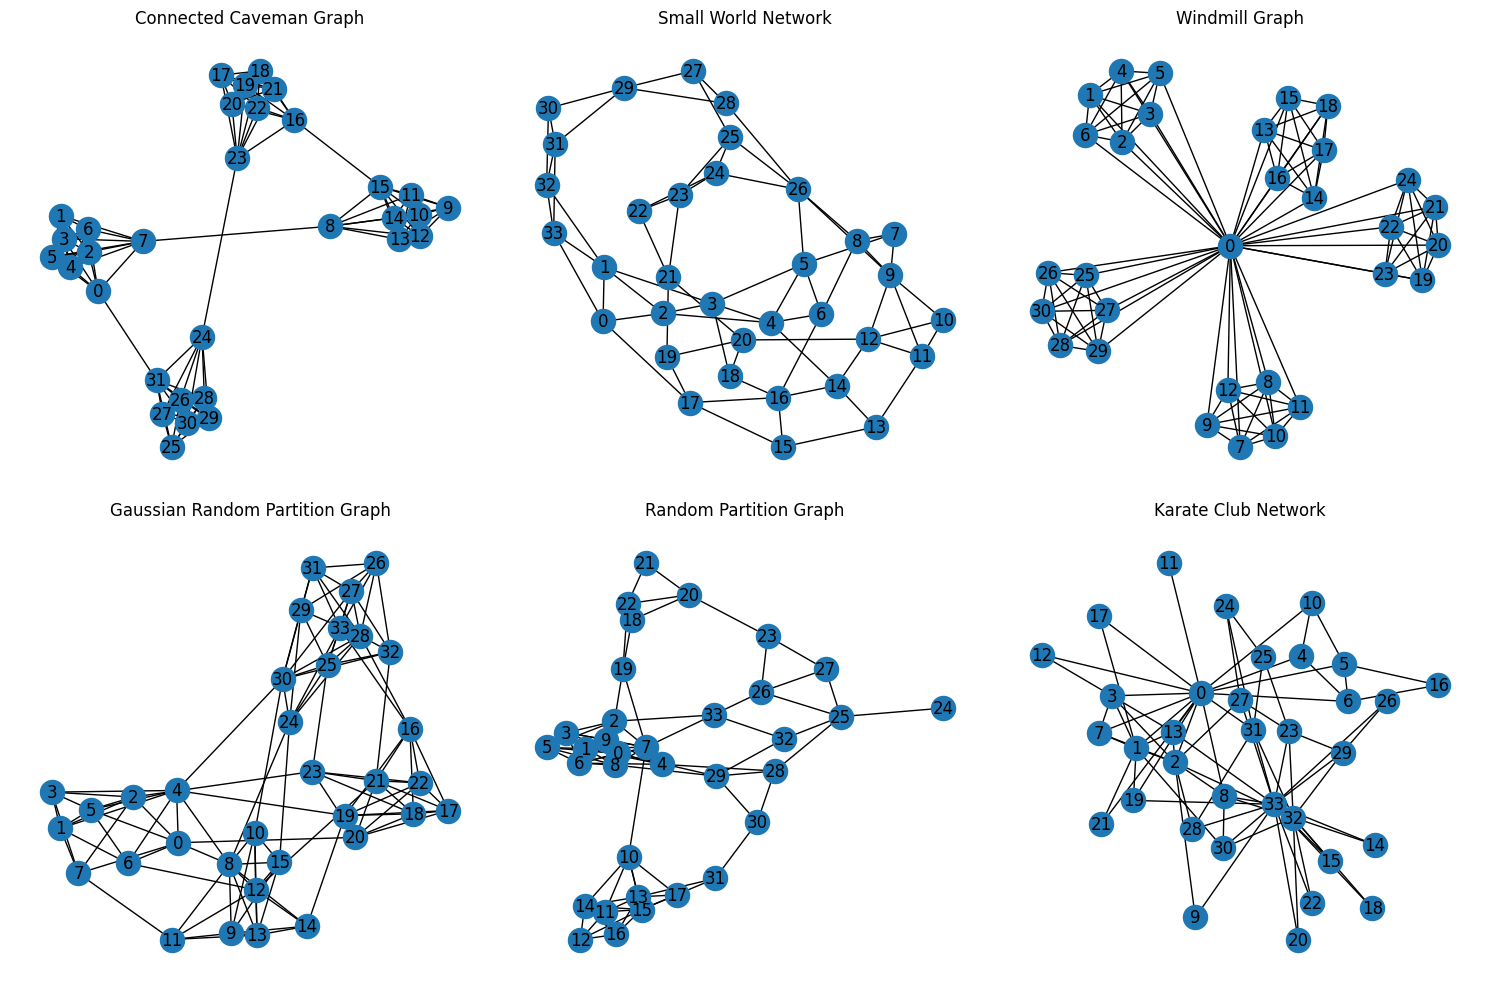

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
nx.draw(connected_caveman_graph, ax=axes[0, 0], with_labels=True)
axes[0, 0].set_title("Connected Caveman Graph")
nx.draw(small_world_network, ax=axes[0, 1], with_labels=True)
axes[0, 1].set_title("Small World Network")
nx.draw(windmill_graph, ax=axes[0, 2], with_labels=True)
axes[0, 2].set_title("Windmill Graph")
nx.draw(gaussian_random_partition_graph, ax=axes[1, 0], with_labels=True)
axes[1, 0].set_title("Gaussian Random Partition Graph")
nx.draw(random_partition_graph, ax=axes[1, 1], with_labels=True)
axes[1, 1].set_title("Random Partition Graph")
nx.draw(karate_club_network, ax=axes[1, 2], with_labels=True)
axes[1, 2].set_title("Karate Club Network")
plt.tight_layout()
plt.show()


## Cliques identification

### Task 2
Calculate the number of different size cliques present in each network and visualize them on a barplot.

Analyse and interpret the obtained results, write your conclusions in the cell below. What does the number of cliques says about those networks? Are they differnt or quite similar?

#### Code

In [14]:
import pandas as pd

Cliques in the graph: [[7, 8], [7, 2, 3, 4, 5, 6, 0], [7, 2, 3, 4, 5, 6, 1], [9, 10, 11, 12, 13, 14, 15], [10, 8, 11, 12, 13, 14, 15], [15, 16], [16, 18, 19, 20, 21, 22, 23], [17, 18, 19, 20, 21, 22, 23], [23, 24], [24, 26, 27, 28, 29, 30, 31], [25, 26, 27, 28, 29, 30, 31], [31, 0]]
Cliques in the graph: [[0, 1, 33], [0, 1, 2], [0, 17], [1, 32, 33], [1, 3, 2], [2, 4, 3], [3, 18], [3, 5, 4], [4, 6, 5], [4, 14], [5, 26], [5, 7], [6, 8], [6, 16], [9, 8, 26], [9, 8, 7], [9, 10, 11, 12], [13, 11], [13, 14], [13, 15], [14, 16], [14, 12], [15, 16, 17], [16, 18], [17, 19], [18, 20], [19, 20, 21], [20, 12], [21, 22, 23], [22, 24, 23], [23, 24, 25], [24, 25, 26], [25, 27], [27, 28, 29], [28, 26], [29, 30, 31], [30, 32, 31], [31, 32, 33]]
Cliques in the graph: [[0, 1, 2, 3, 4, 5, 6], [0, 7, 8, 9, 10, 11, 12], [0, 13, 14, 16, 17, 18, 15], [0, 19, 20, 24, 21, 22, 23], [0, 25, 26, 27, 28, 29, 30]]
Cliques in the graph: [[1, 3, 2, 5], [1, 3, 2, 7], [1, 3, 4, 5], [1, 6, 4, 5], [2, 0, 5], [2, 0, 7], [2

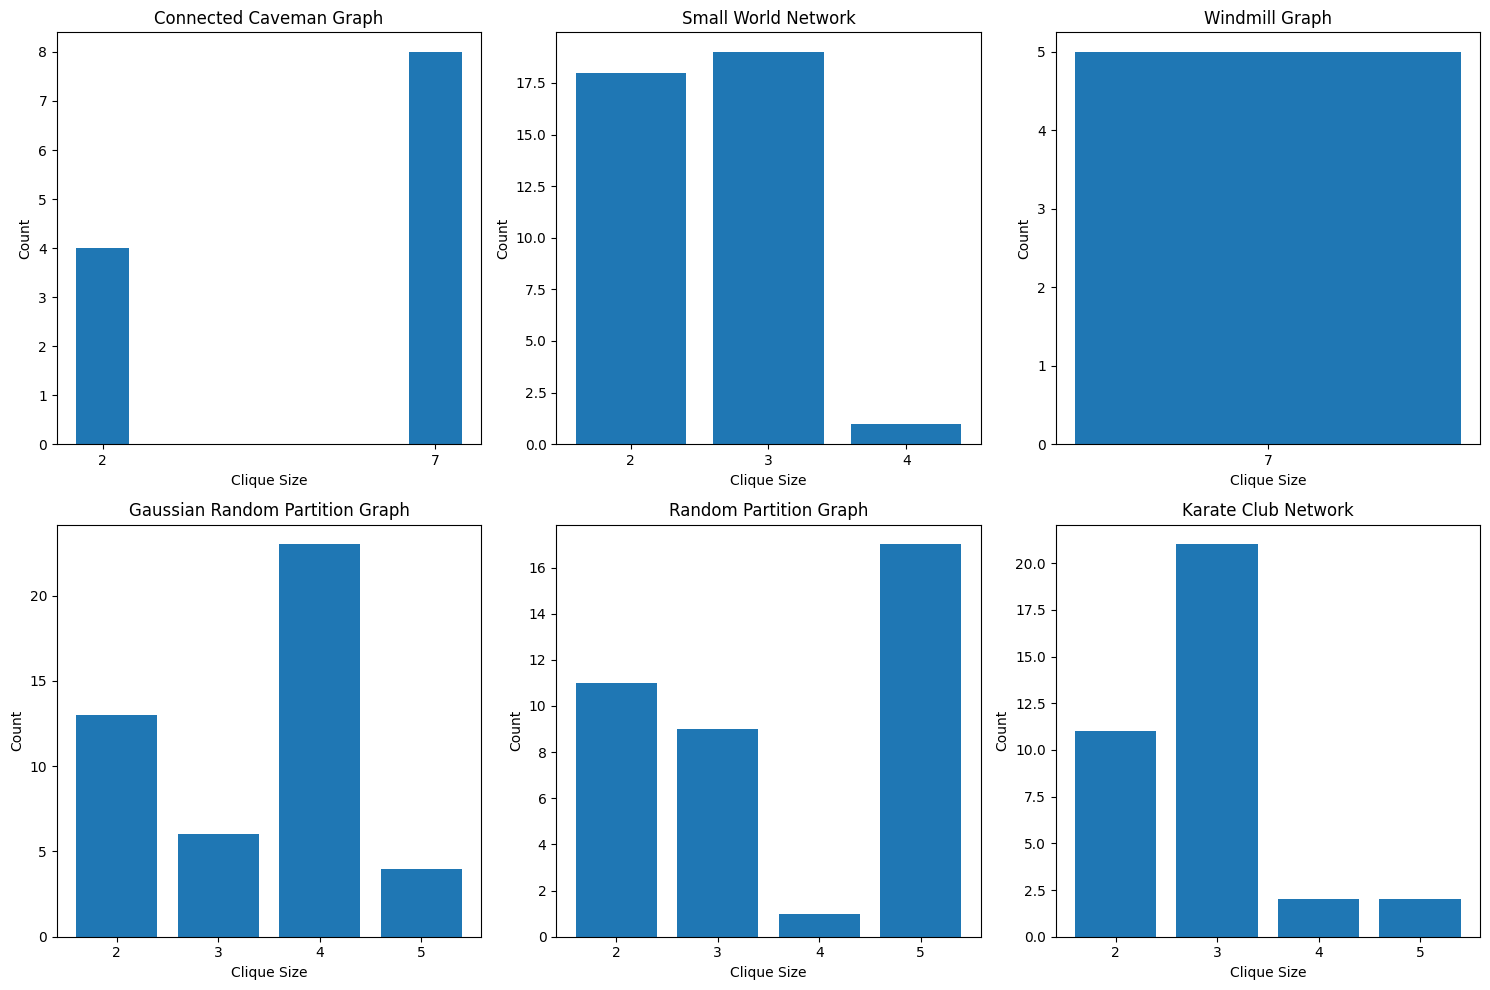

In [26]:
def count_cliques(graph):
    cliques = list(nx.find_cliques(graph))
    print(f"Cliques in the graph: {cliques}")
    clique_sizes = [len(clique) for clique in cliques]
    size_counts = {}
    for size in clique_sizes:
        if size not in size_counts:
            size_counts[size] = 0
        size_counts[size] += 1
    return size_counts

graphs = {
    "Connected Caveman Graph": connected_caveman_graph,
    "Small World Network": small_world_network,
    "Windmill Graph": windmill_graph,
    "Gaussian Random Partition Graph": gaussian_random_partition_graph,
    "Random Partition Graph": random_partition_graph,
    "Karate Club Network": karate_club_network
}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for idx, (name, graph) in enumerate(graphs.items()):
    size_counts = count_cliques(graph)
    sizes = list(size_counts.keys())
    counts = list(size_counts.values())
    axes[idx // 3, idx % 3].bar(sizes, counts)
    axes[idx // 3, idx % 3].set_title(name)
    axes[idx // 3, idx % 3].set_xlabel("Clique Size")
    axes[idx // 3, idx % 3].set_ylabel("Count")
    axes[idx // 3, idx % 3].set_xticks(sizes)
plt.tight_layout()
plt.show()

#### Conclusions

- Connected Caveman Graph ma wyraźnie dwie grupy klik: małe (rozmiar 2, czyli krawędzie) i duże (rozmiar 7 —> k-1 wierzchołków jaskini). To idealny przykład grafu z wyraźną strukturą klastrowości — każda jaskinia tworzy klikę, a połączenia między nimi to tylko pojedyncze krawędzie

- Small World Network zawiera głównie kliki rozmiaru 2 i 3, z nielicznymi czwórkami. Wynika to z tego, ze kazdy węzeł jest początkowo połączony lokalnie, a następnie część krawędzi jest losowo przepinana z podanym prawdopodobieństwem p. Lokalność tej struktury połączeń sprzyja więc tworzeniu małych, gęstyuch grup, ale nie duzych pełnych podgrafów

- Windmill Graph ma jedną, bardzo wyraźną klikę rozmiaru 7 — środkowy "hub" połączony ze wszystkimi łopatkami. Struktura jest deterministyczna i regularna — brak różnorodności rozmiarów klik oraz niewielka ich liczba

- W grafach typu Random Partition oraz Gaussian Random Partition liczba klik jest umiarkowana, a ich rozmiary są zróżnicowane. Wynika to z parametrów p_in i p_out, które kontrolują gęstość połączeń wewnątrz i między grupami. Wysokie p_in​ sprzyja powstawaniu klik wewnątrz grup, natomiast niskie p_out ogranicza ich łączenie się w większe struktury

- Karate Club Network ma podobną strukturę klik co poprzednio opisane grafy Random Partition. Równiez występuje tutaj zróznicowanie wymiarów kliki, przy czym większą ich część stanowią kliki małe i średnie

Sieci różnią się znacząco rozkładem klik. Grafy generowane z wyraźną strukturą (Caveman, Windmill) mają jednolite, duże kliki, natomiast sieci losowe i rzeczywiste mają więcej róznych rozmiarów klik, o mniejszym stopniu

## Hierarchical clustering using Girvan–Newman algorithm

The Girvan–Newman algorithm is a popular method for detecting communities in complex networks. It is based on the concept of edge betweenness centrality and operates by iteratively removing edges with the highest betweenness centrality. This process effectively breaks the network into smaller components, which can then be interpreted as communities.

The algorithm's steps
1. The betweenness of all existing edges in the network is calculated first.
2. The edge(s) with the highest betweenness are removed.
3. The betweenness of all edges affected by the removal is recalculated.
4. Steps 2 and 3 are repeated until no edges remain.

### Task 3
Use Girvan–Newman algorithm to detect communities among all studied networks. Use NetworkX function ```nx.algorithms.community.girvan_newman(G)```. Visualize and inspect obtained results for different numbers of communities. Find the best split for each network using modularity as a goodness measure and plot partitioned networks. Save the modularity results for each network for later comparison with other community detection method.

#### Code

In [27]:
import itertools
from networkx.algorithms.community import girvan_newman
from networkx.algorithms.community.quality import modularity

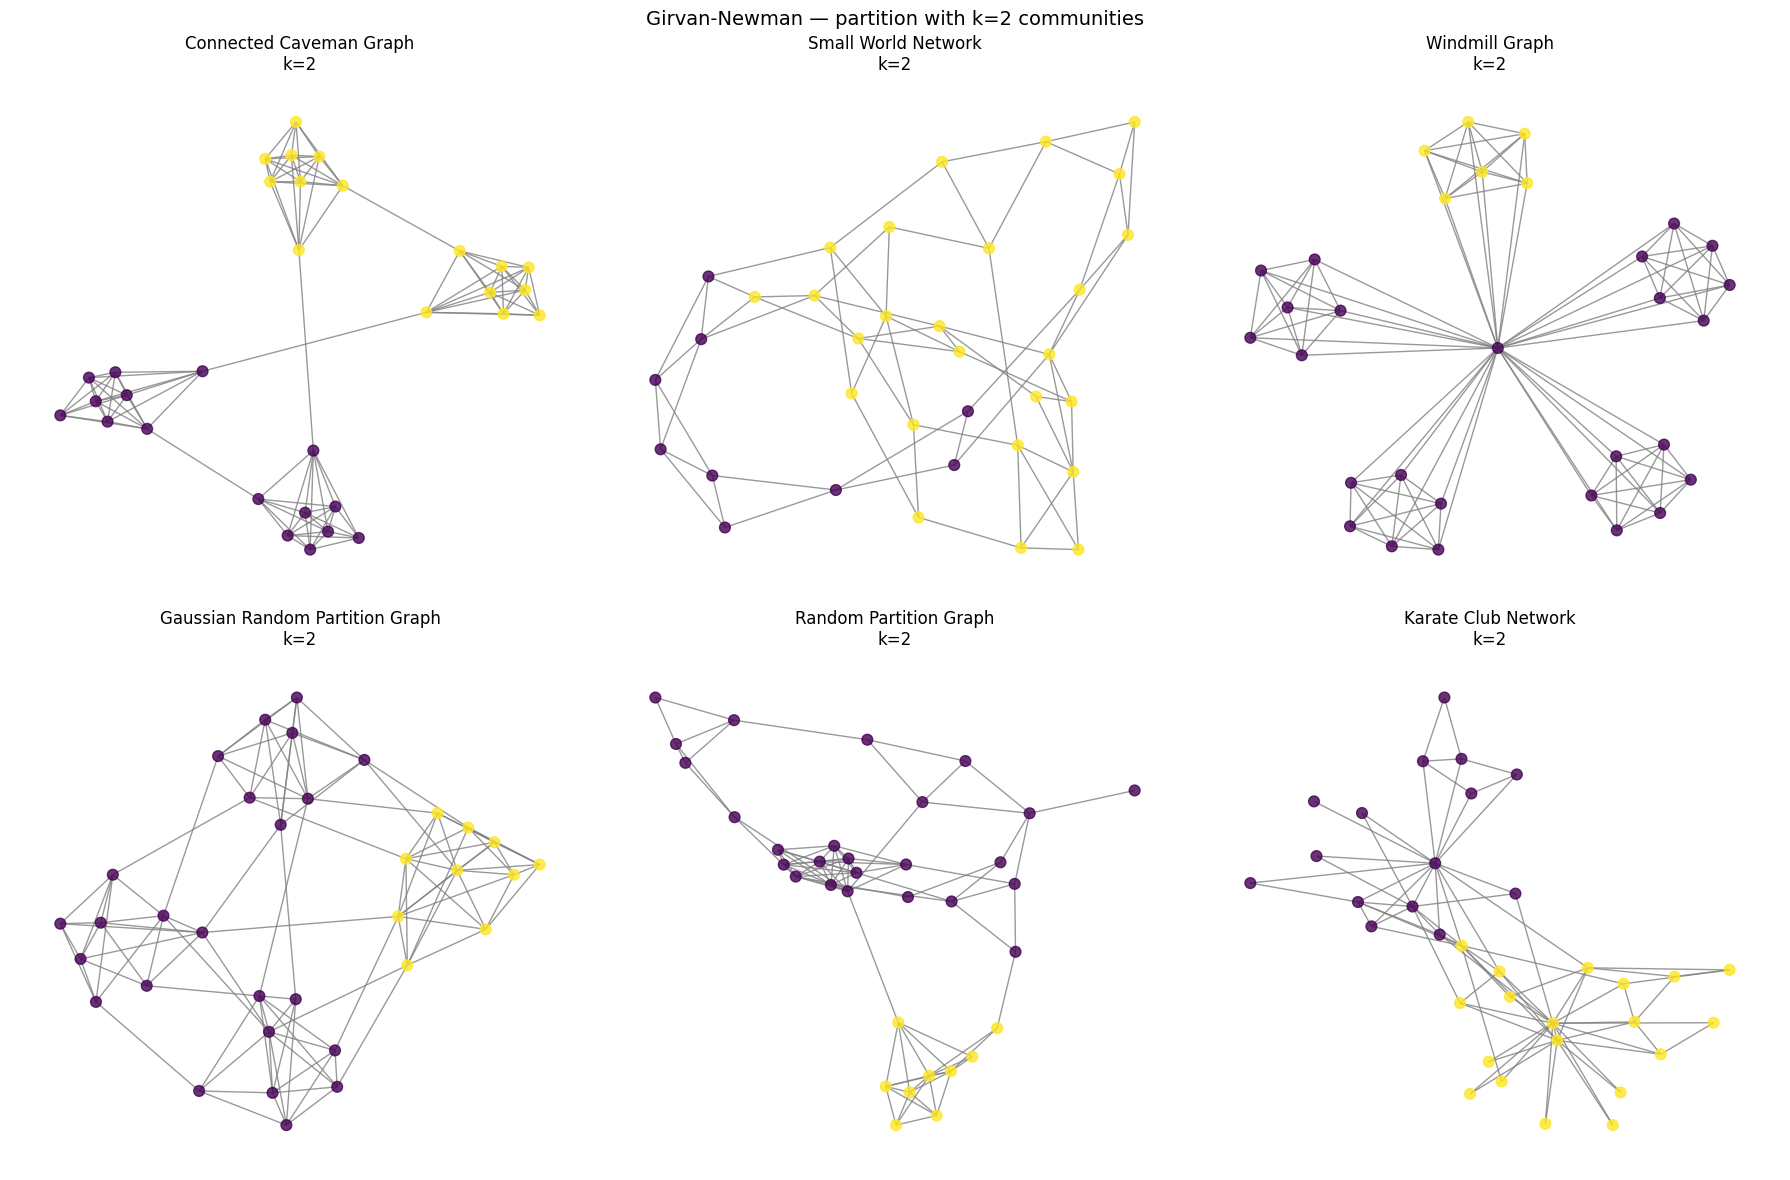

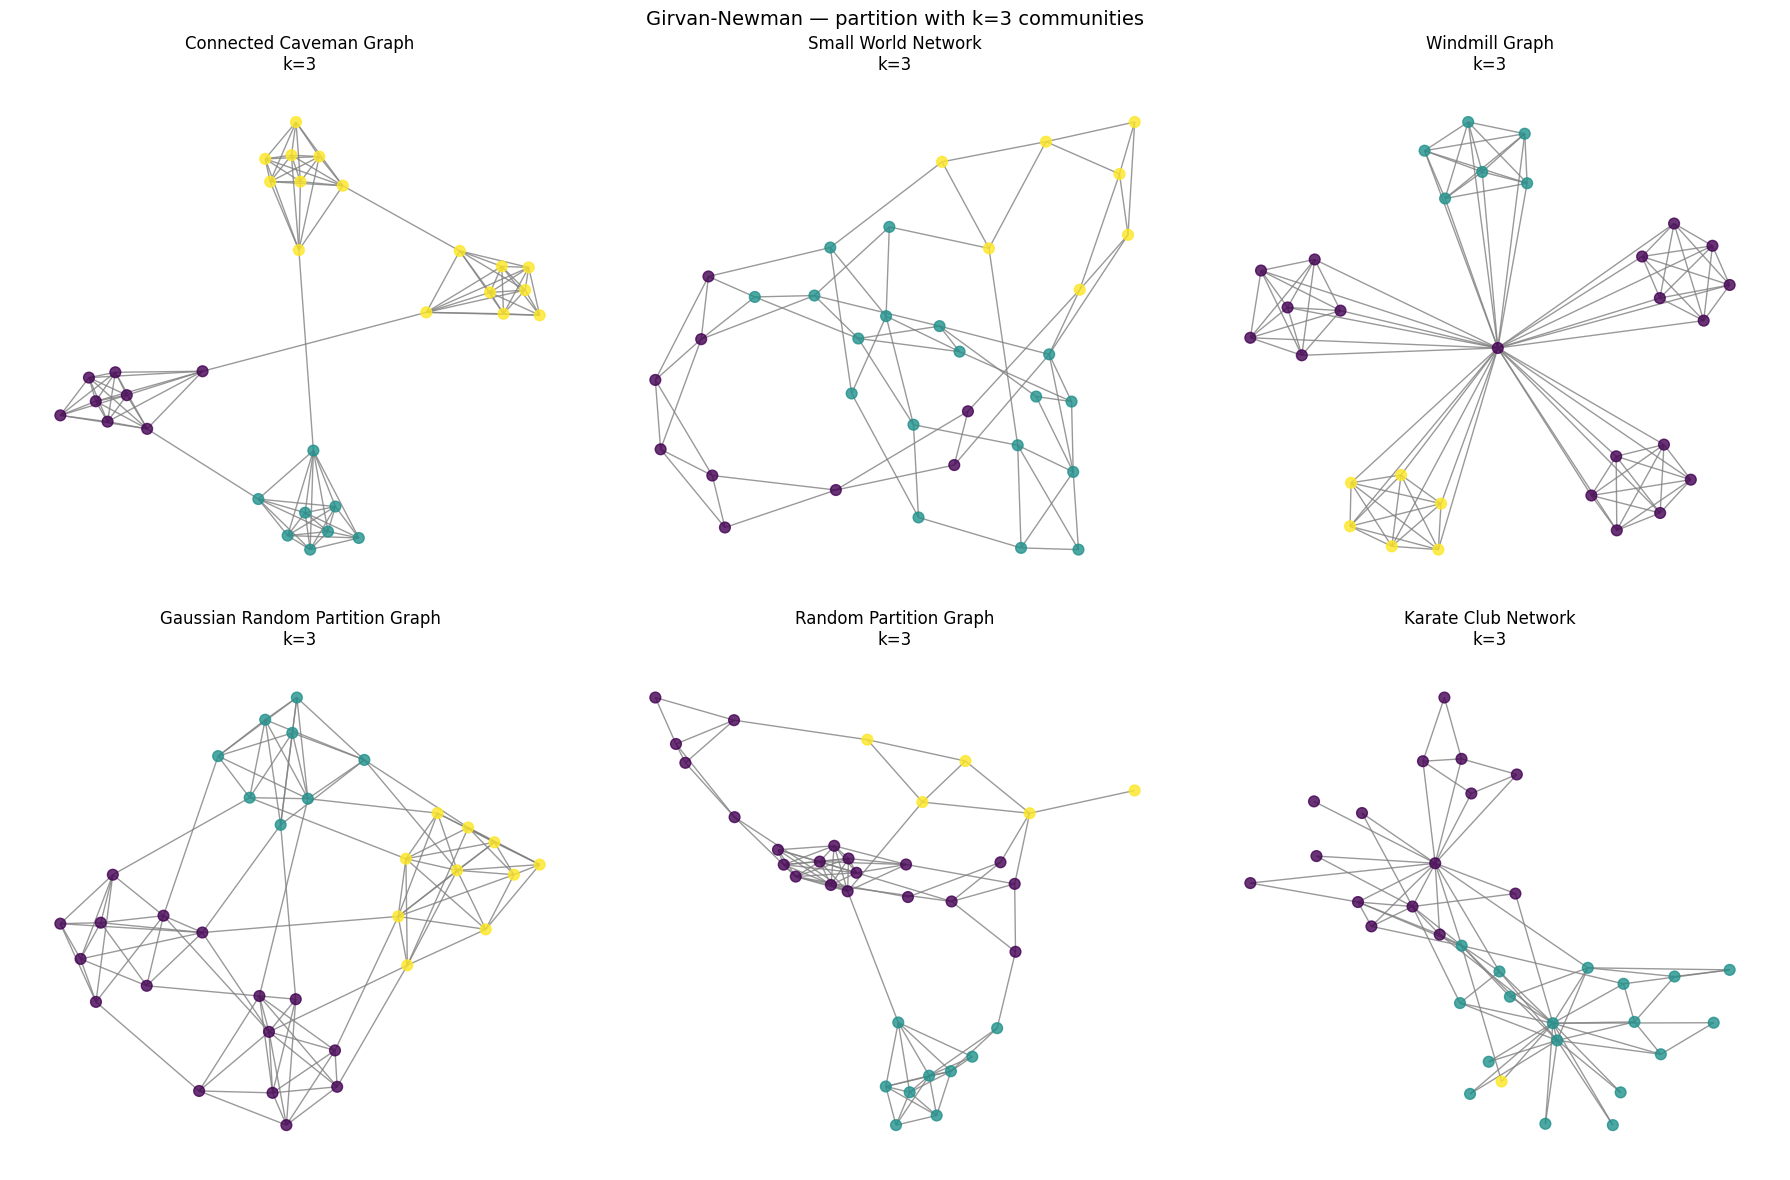

In [30]:
def specific_num_communities_girvan_newman(G, num_communities):
    comp = girvan_newman(G)
    for communities in itertools.islice(comp, num_communities - 1):
        partition = list(communities)
        if len(partition) == num_communities:
            return partition
    return None

def plot_partitioned_girvan_newman(graph, num_communities):
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    for idx, (name, graph) in enumerate(graphs.items()):
        ax = axes[idx // 3, idx % 3]
        partition = specific_num_communities_girvan_newman(graph, num_communities=num_communities)
    
        pos = nx.spring_layout(graph, seed=42)
        color_map = []
        for node in graph.nodes:
            for i, cluster in enumerate(partition):
                if node in cluster:
                    color_map.append(i)
                    break

        nx.draw_networkx(graph, pos=pos, ax=ax, node_color=color_map, with_labels=False, node_size=60, edge_color="gray", alpha=0.8)
        ax.set_title(f"{name}\nk={num_communities}")
        ax.axis("off")
    plt.suptitle(f"Girvan-Newman — partition with k={num_communities} communities", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_partitioned_girvan_newman(graphs, num_communities=2)
plot_partitioned_girvan_newman(graphs, num_communities=3)

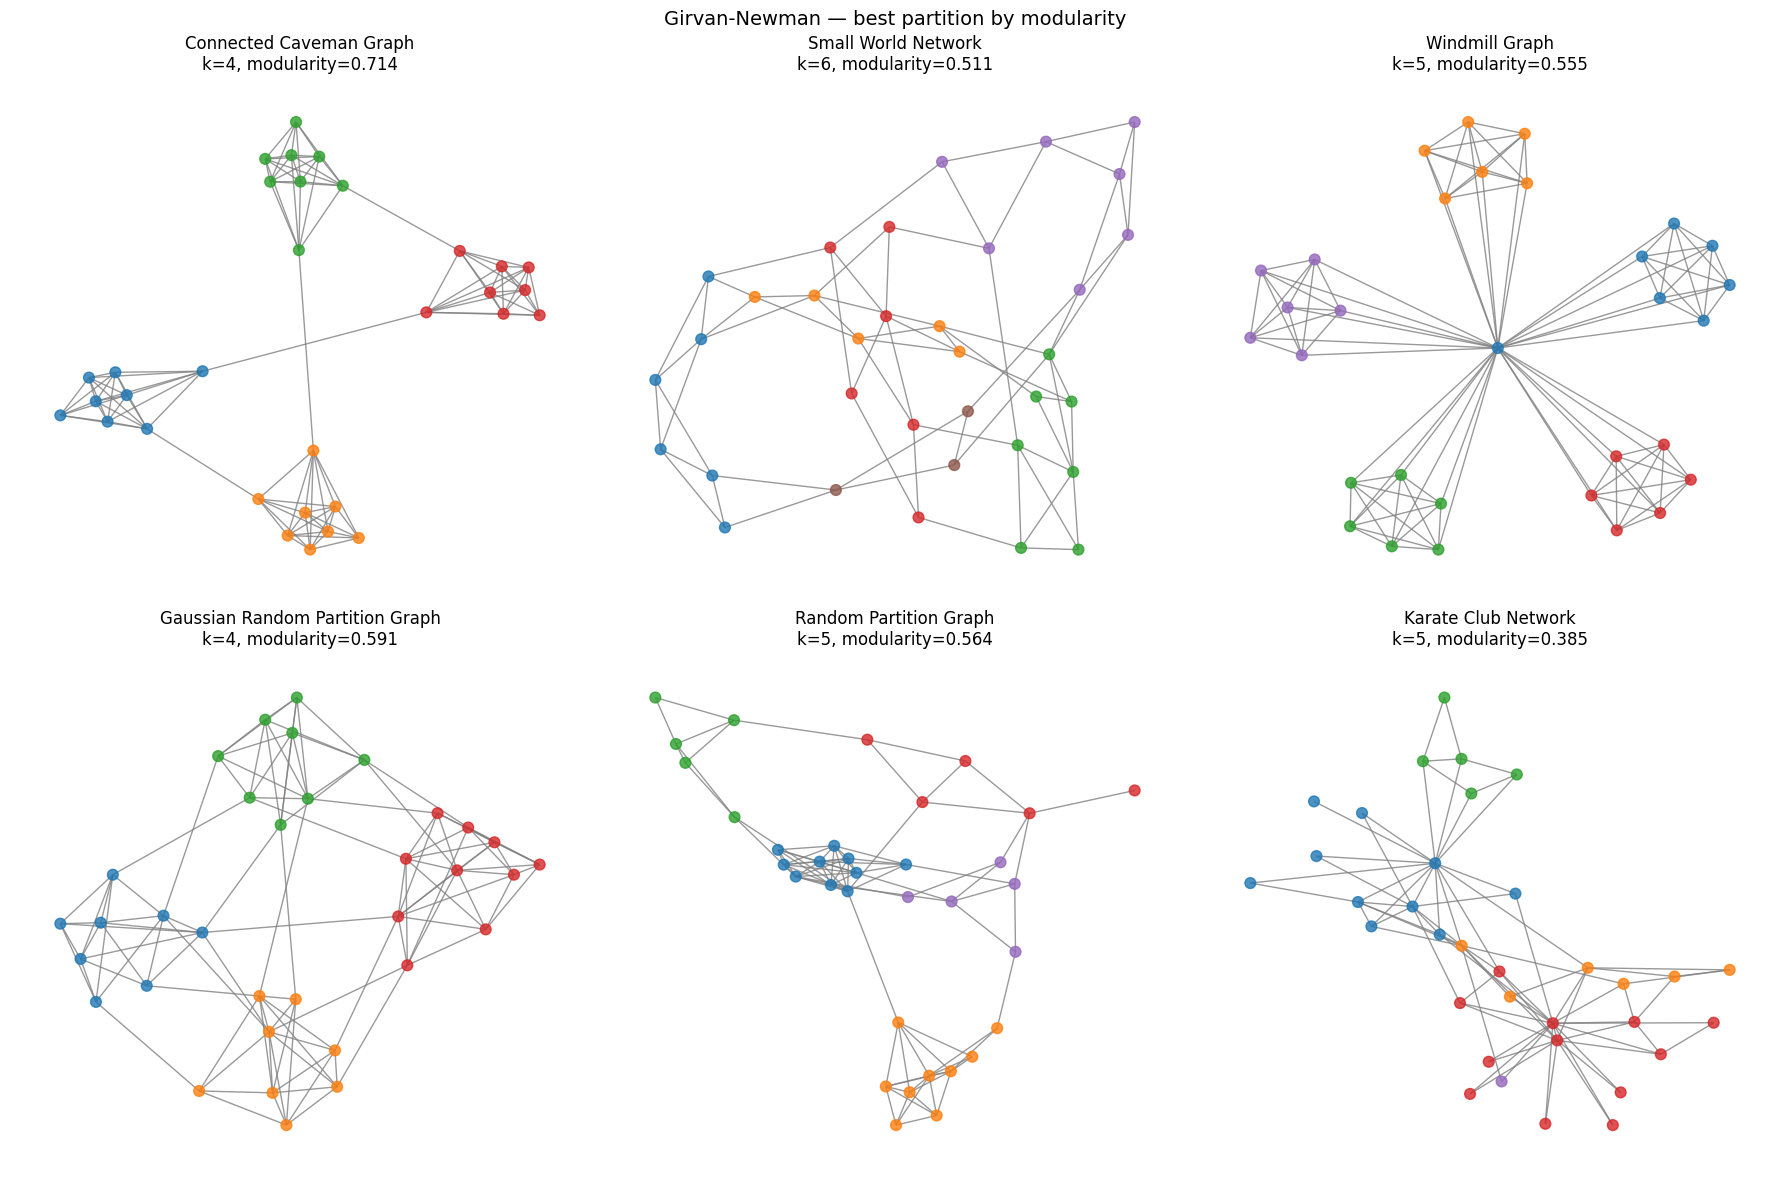

Connected Caveman Graph: k=4, modularity=0.7143
Small World Network: k=6, modularity=0.5114
Windmill Graph: k=5, modularity=0.5551
Gaussian Random Partition Graph: k=4, modularity=0.5909
Random Partition Graph: k=5, modularity=0.5641
Karate Club Network: k=5, modularity=0.3850


In [29]:
def best_girvan_newman(G):
    comp = girvan_newman(G)
    best_mod = -1
    best_partition = None
    best_k = 0
    modularity_scores = {}

    for communities in comp:
        partition = list(communities)
        k = len(partition)
        try:
            mod = modularity(G, partition)
        except Exception:
            mod = -1
        modularity_scores[k] = mod
        if mod > best_mod:
            best_mod = mod
            best_partition = partition
            best_k = k

    return best_partition, best_mod, best_k, modularity_scores

gn_results = {}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for idx, (name, graph) in enumerate(graphs.items()):
    ax = axes[idx // 3, idx % 3]
    partition, best_mod, best_k, scores = best_girvan_newman(graph)
    gn_results[name] = {"modularity": best_mod, "n_communities": best_k, "partition": partition}

    pos = nx.spring_layout(graph, seed=42)
    colors = plt.cm.tab10.colors
    color_map = []
    for node in graph.nodes():
        for i, comm in enumerate(partition):
            if node in comm:
                color_map.append(colors[i % 10])
                break

    nx.draw_networkx(graph, pos=pos, ax=ax, node_color=color_map, with_labels=False, node_size=60, edge_color="gray", alpha=0.8)
    ax.set_title(f"{name}\nk={best_k}, modularity={best_mod:.3f}")
    ax.axis("off")

plt.suptitle("Girvan-Newman — best partition by modularity", fontsize=14)
plt.tight_layout()
plt.show()

for name, res in gn_results.items():
    print(f"{name}: k={res['n_communities']}, modularity={res['modularity']:.4f}")


## Modularity based community detection using Louvain algorithm
The Louvain algorithm is the most popular community detection algorithm. Its operation is based on the optimization of modularity. Louvain can be used even with very large networks with millions of nodes and edges.

### Louvain algorithm
1. Start with each node assigned to its own group.
2. Loop over nodes:

  2.1. Assign the node to the neighbor community that will give you the largest modularity increase.

  2.2. Repeat step 2.1 until no further modularity increase is possible.
3. Transform your network into a super network.

  3.1. Each community becomes a supernode.

  3.2. Assign weights to the edges corresponding to the number of connections within and between the groups.
4. Repeat step 2 until no further modularity increase is possible.


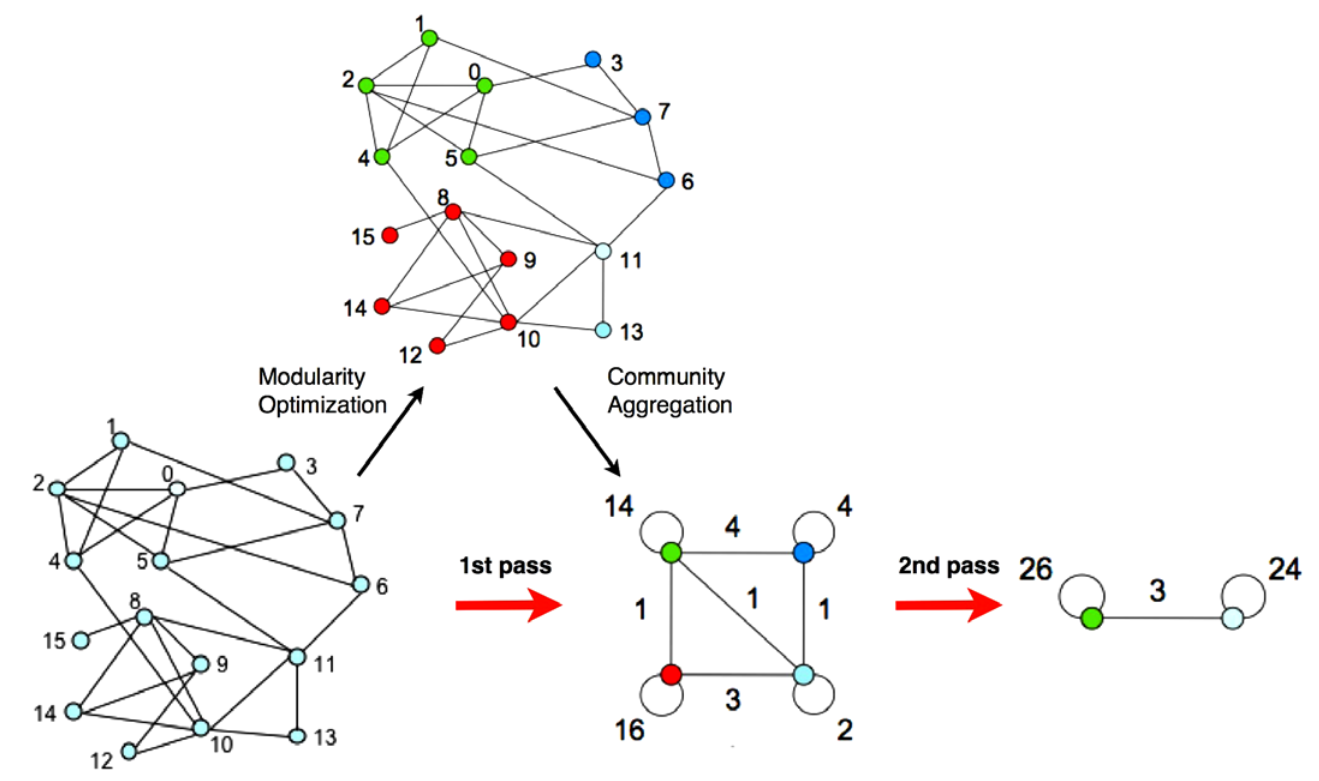

### Task 4
Use Louvain algorithm to detect communities among all studied networks. Use NetworkX function ```nx.community.louvain_communities(G, seed)```. Visualize and inspect the results.

Analyse and interpret the obtained communities, write your conclusions in the cell below.

 - Can we consider the produced split an optimal one? Change the seed value and check how it influences the obtained results, can you explain why the splits are sometimes different?

 - Compare the modularity value for generated partitions between Louvain algorithm and Girvan-Newmann algorithm. Which one is better in your opinion?

#### Code

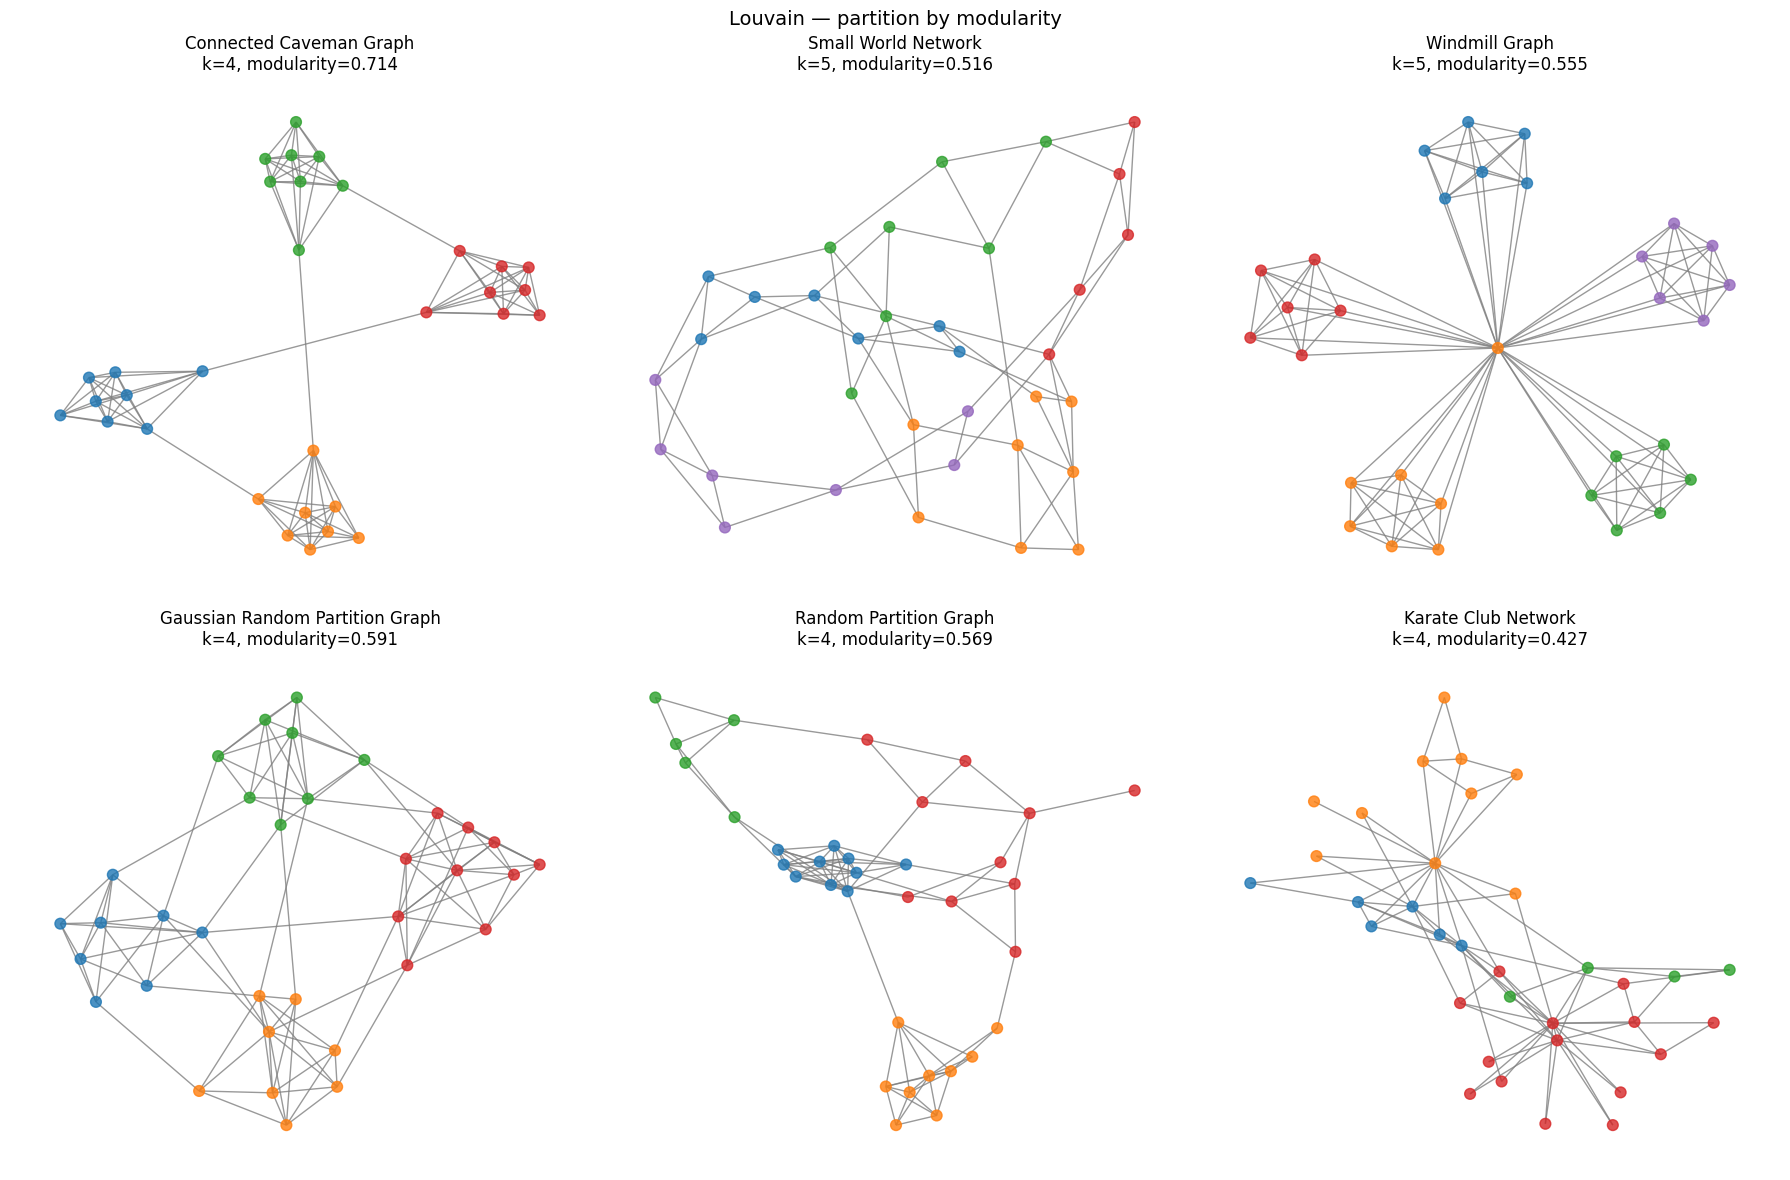

In [31]:
louvain_results = {}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
for idx, (name, graph) in enumerate(graphs.items()):
    ax = axes[idx // 3, idx % 3]
    partition = nx.community.louvain_communities(graph, seed=42)
    mod = modularity(graph, partition)
    louvain_results[name] = {"modularity": mod, "n_communities": len(partition), "partition": partition}

    pos = nx.spring_layout(graph, seed=42)
    colors = plt.cm.tab10.colors
    color_map = [colors[i % 10] for node in graph.nodes() for i, comm in enumerate(partition) if node in comm]
    nx.draw_networkx(graph, pos=pos, ax=ax, node_color=color_map, with_labels=False, node_size=60, edge_color="gray", alpha=0.8)
    ax.set_title(f"{name}\nk={len(partition)}, modularity={mod:.3f}")
    ax.axis("off")
plt.suptitle("Louvain — partition by modularity", fontsize=14)
plt.tight_layout()
plt.show()

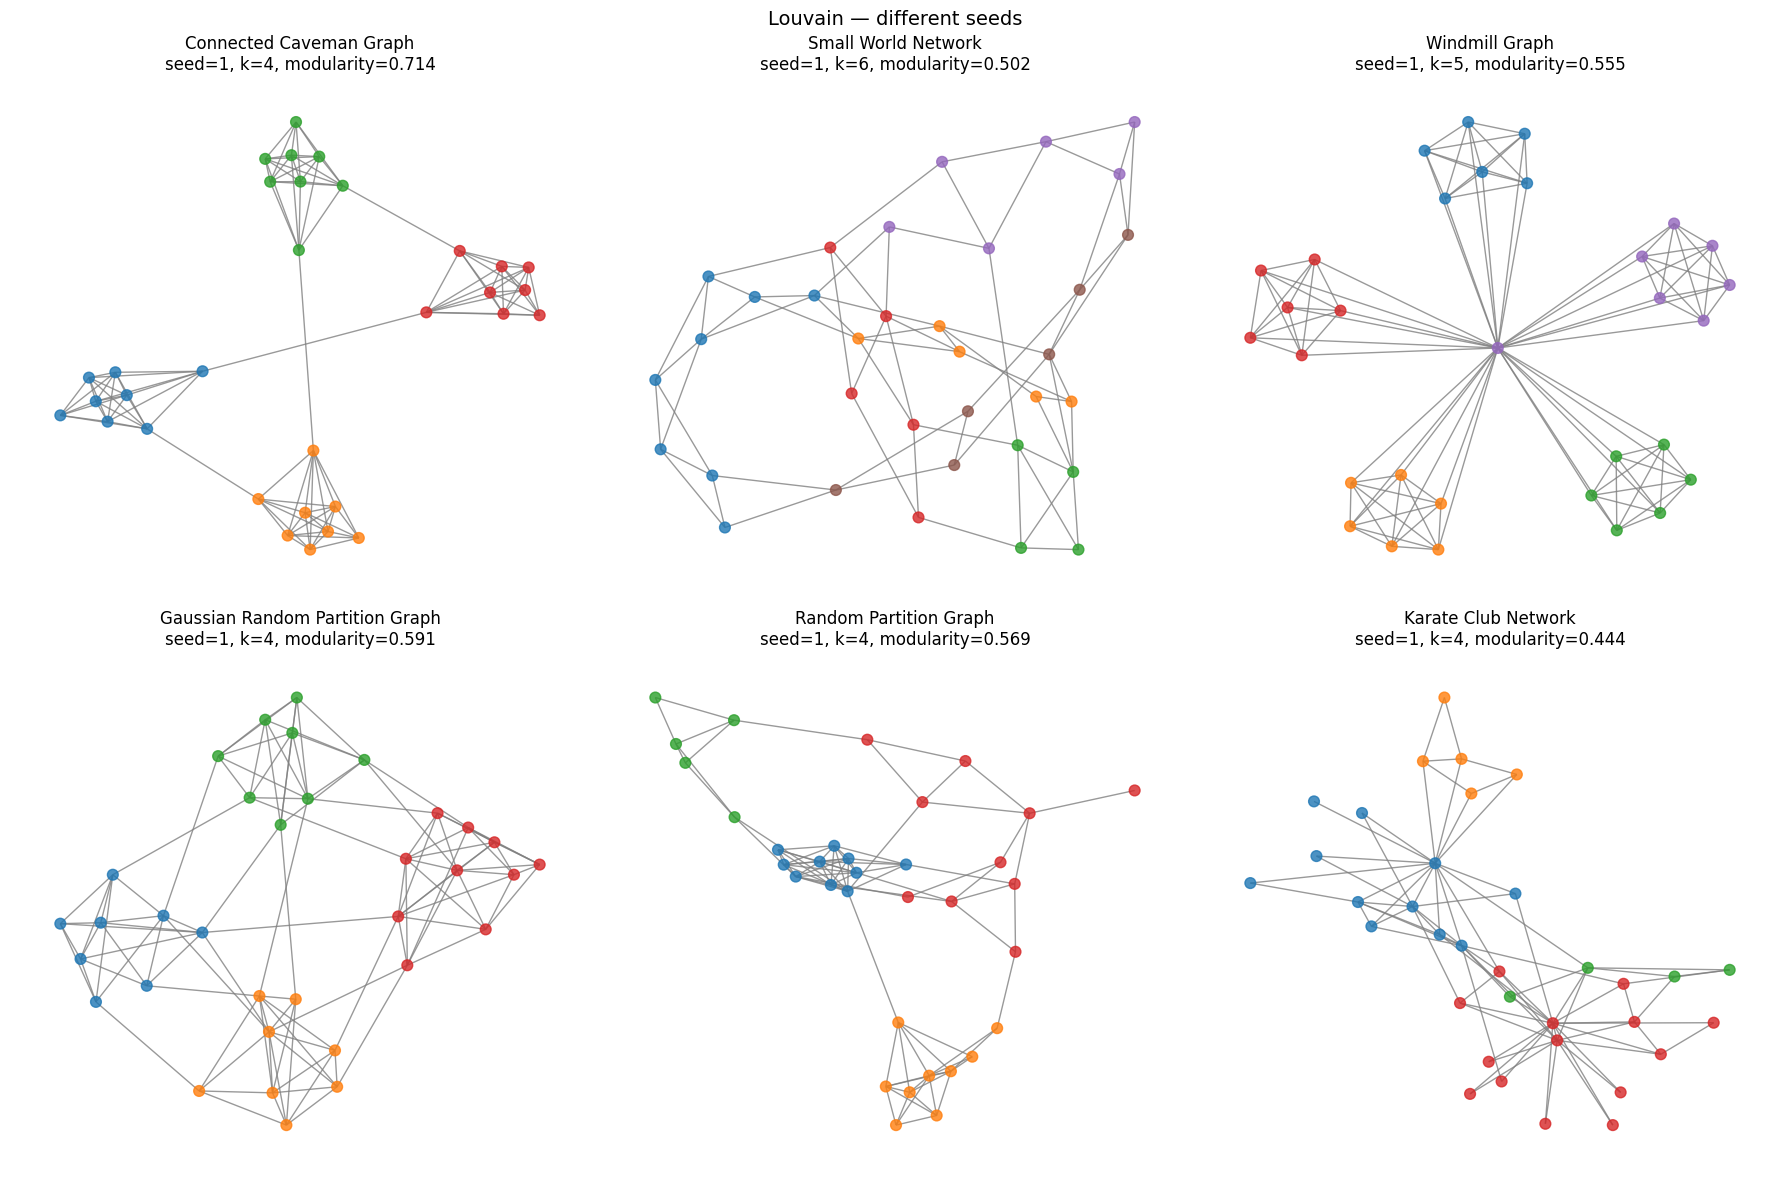

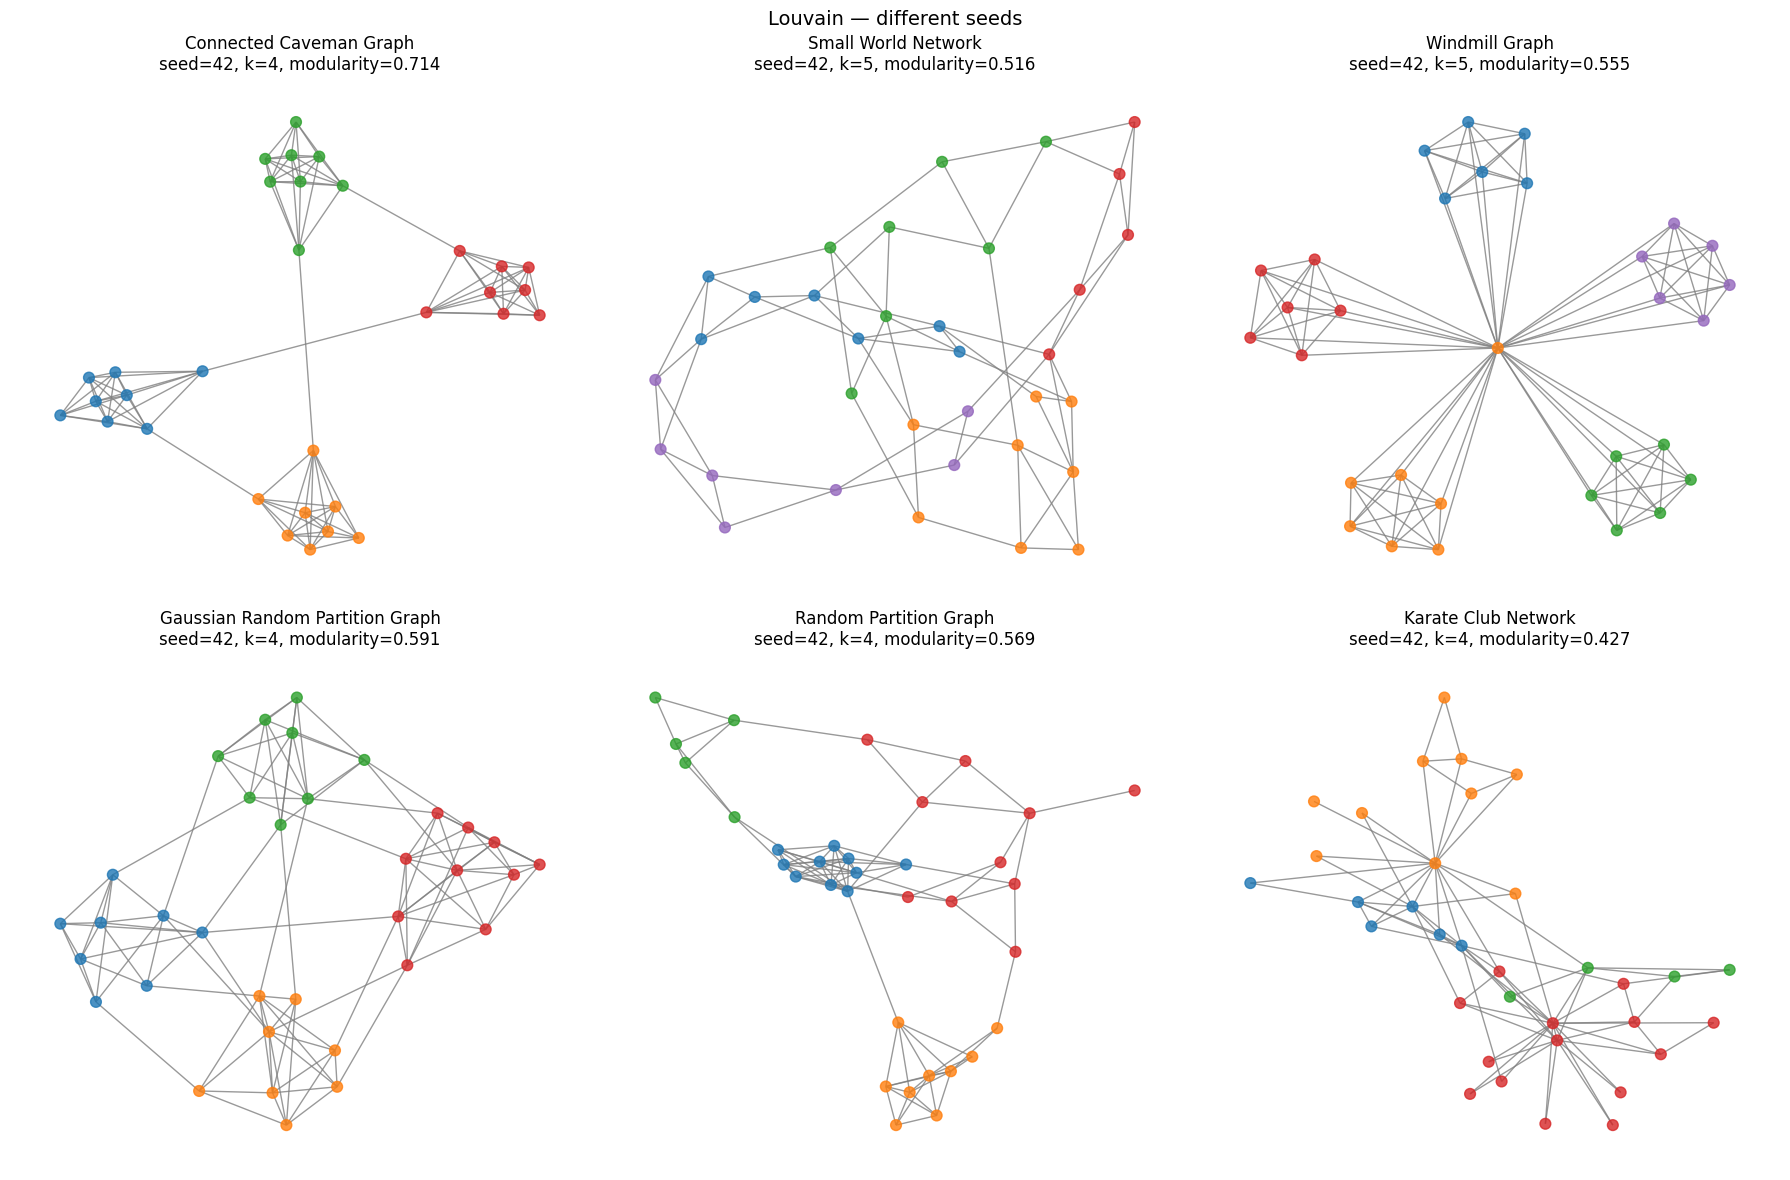

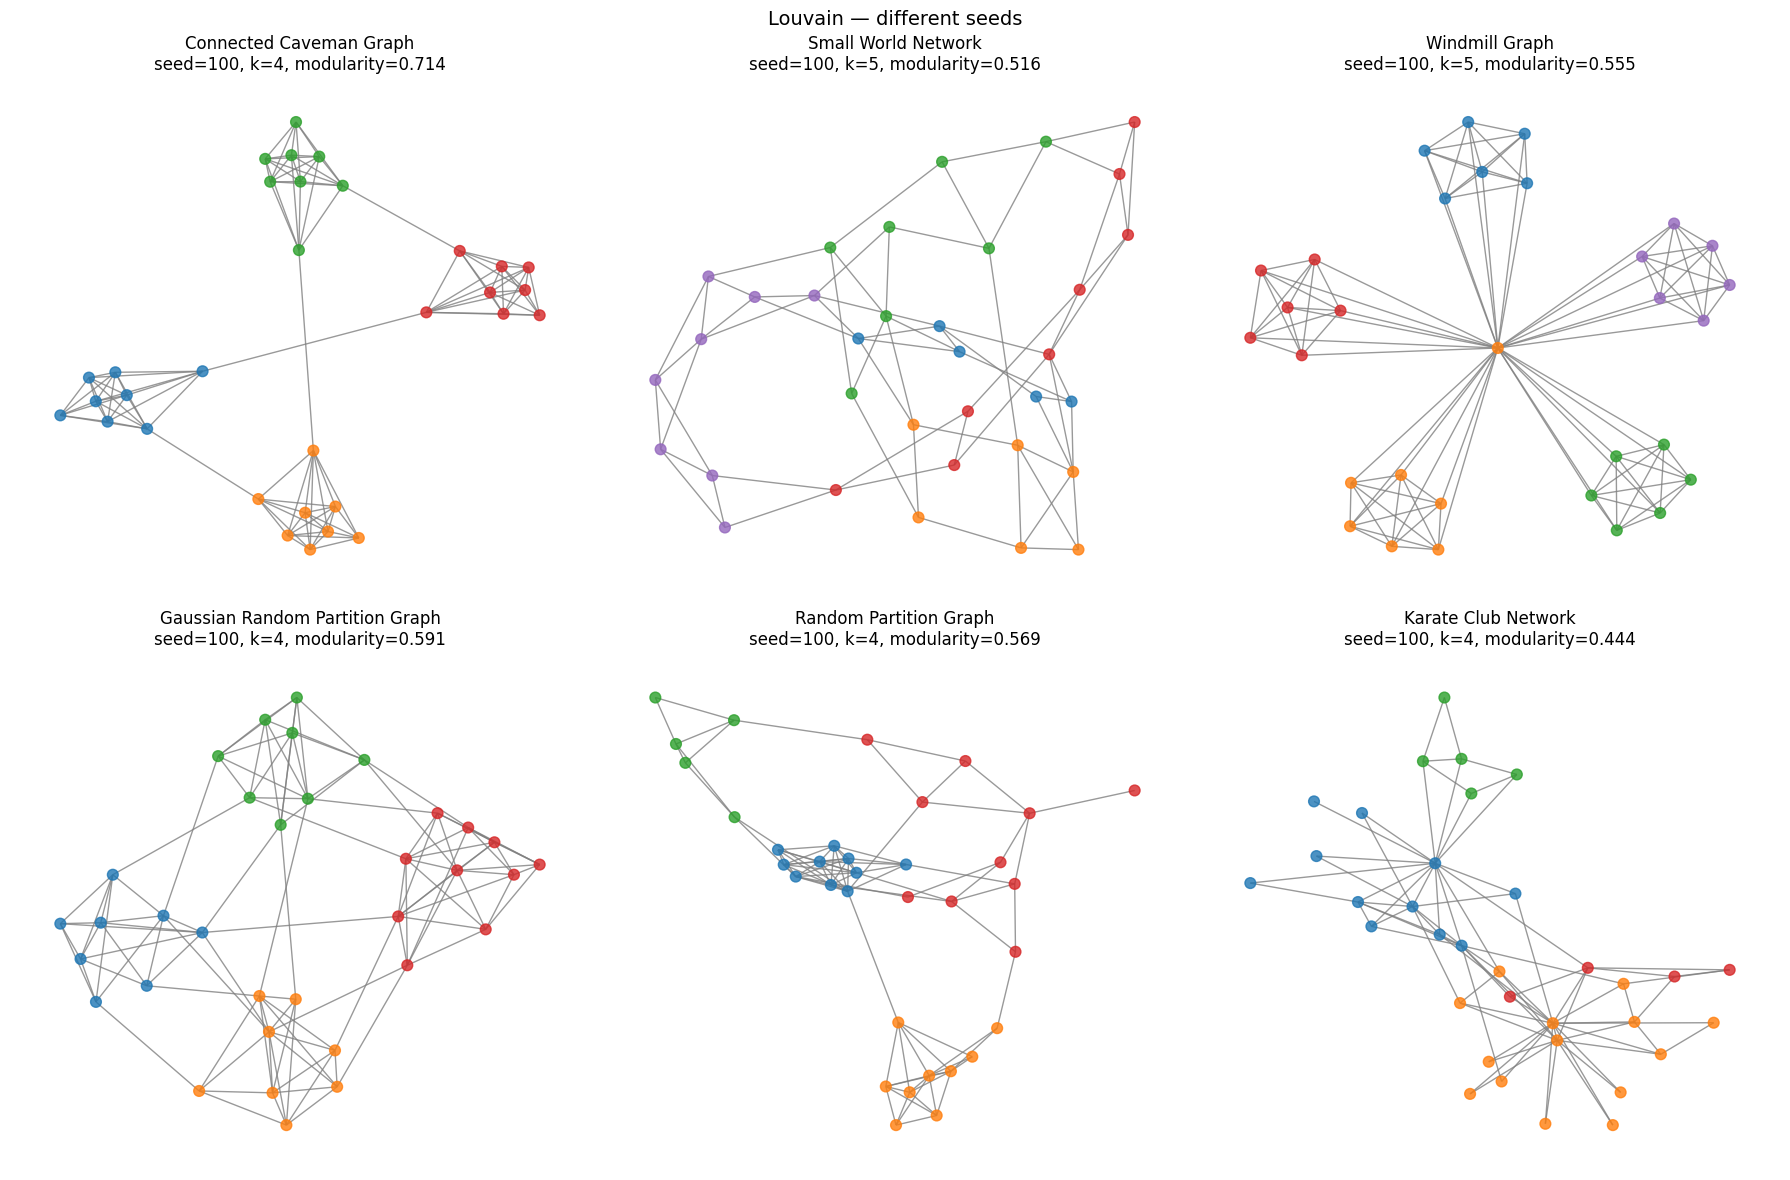

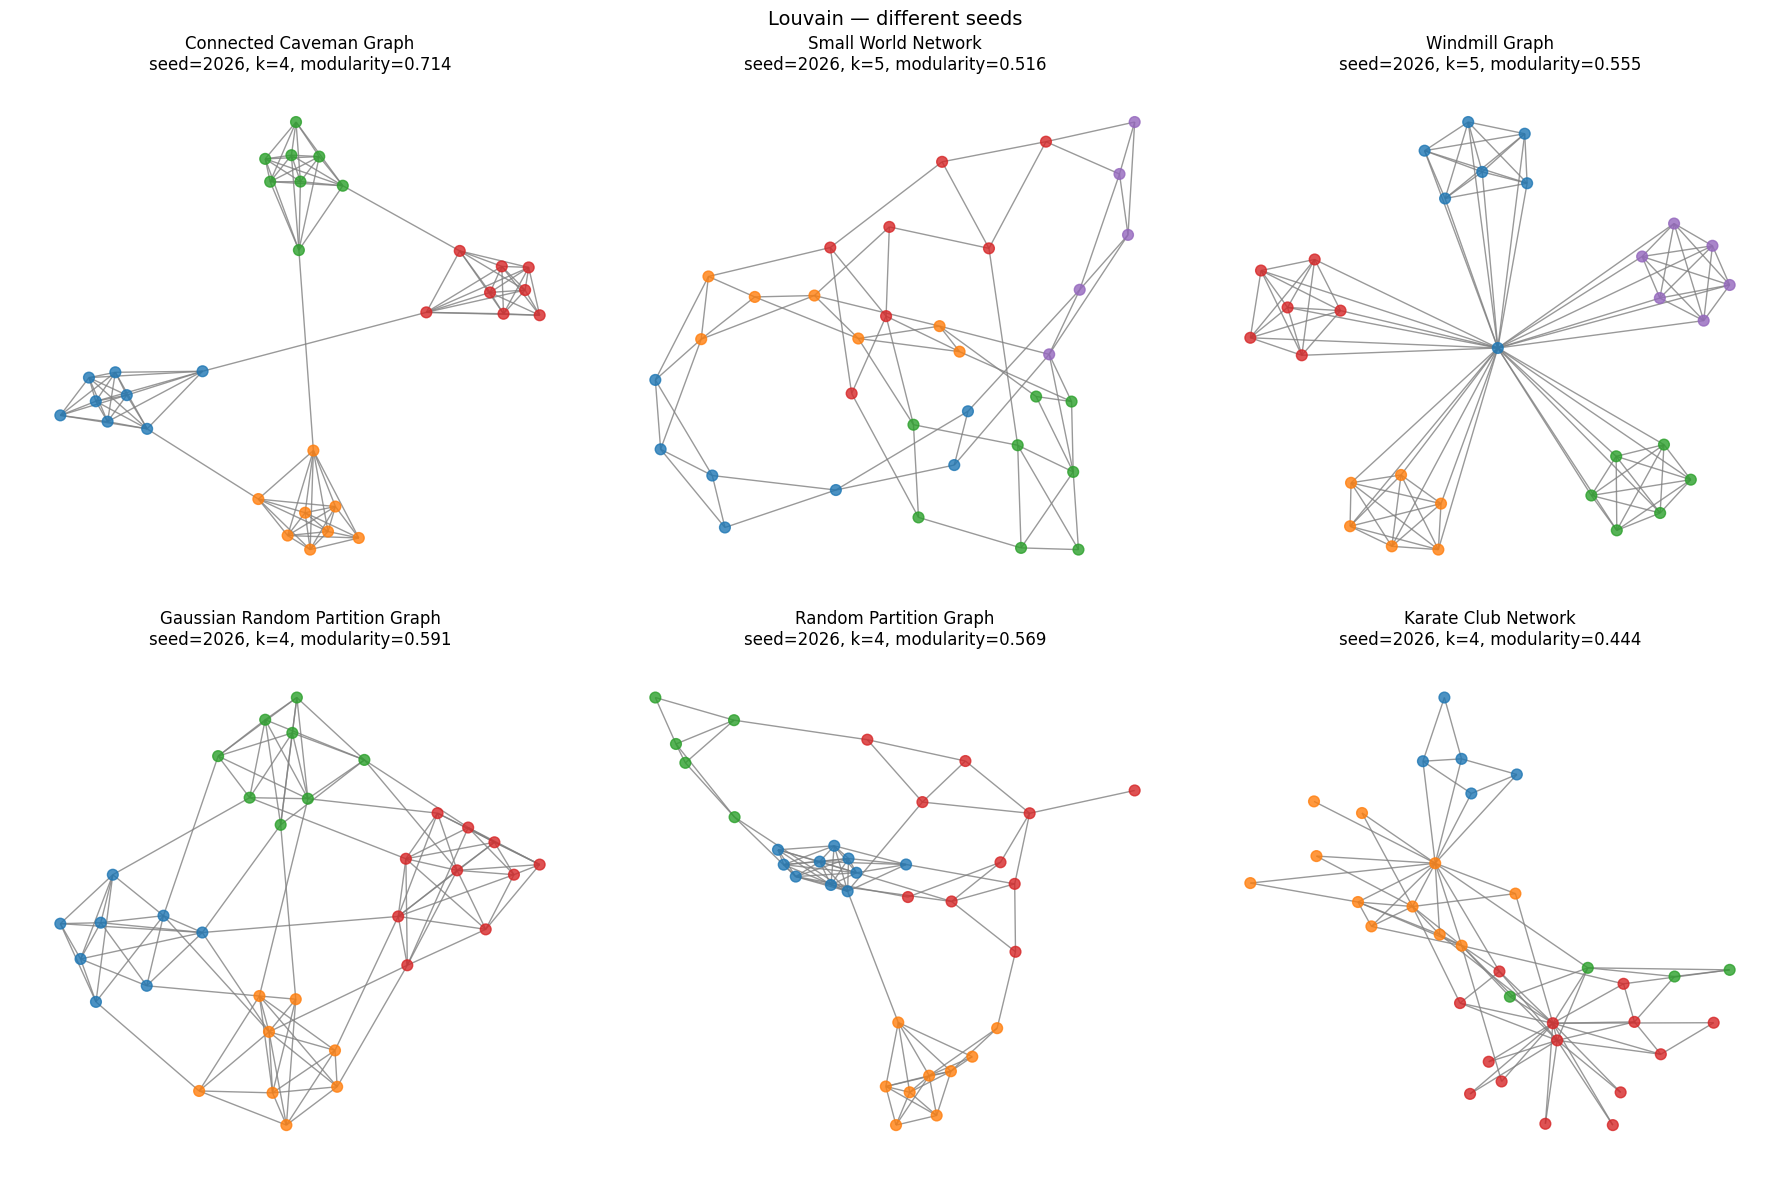

Seed                                  1                        42    \
                                modularity n_communities modularity   
Graph                                                                 
Connected Caveman Graph           0.714286             4   0.714286   
Gaussian Random Partition Graph   0.590902             4   0.590902   
Karate Club Network               0.443854             4   0.426622   
Random Partition Graph            0.569436             4   0.569436   
Small World Network               0.501730             6   0.515679   
Windmill Graph                    0.555102             5   0.555102   

Seed                                                100                 \
                                n_communities modularity n_communities   
Graph                                                                    
Connected Caveman Graph                     4   0.714286             4   
Gaussian Random Partition Graph             4   0.590902             4   
Karate Club Network                         4   0.443854             4   
Random Partition Graph                      4   0.569436             4   
Small World Network                         5   0.515571             5   
Windmill Graph                              5   0.555102             5   

Seed                                  2026                
                                modularity n_communities  
Graph                                                     
Connected Caveman Graph           0.714286             4  
Gaussian Random Partition Graph   0.590902             4  
Karate Club Network               0.443854             4  
Random Partition Graph            0.569436             4  
Small World Network               0.515679             5  
Windmill Graph                    0.555102             5

In [38]:
# different seeds for louvain
seeds = [1, 42, 100, 2026]
louvain_results_different_seeds = {}

for seed in seeds:
    louvain_results_different_seeds[seed] = {}
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    for idx, (name, graph) in enumerate(graphs.items()):
        ax = axes[idx // 3, idx % 3]
        partition = nx.community.louvain_communities(graph, seed=seed)
        mod = modularity(graph, partition)

        louvain_results_different_seeds[seed][name] = {"modularity": mod, "n_communities": len(partition), "partition": partition}

        pos = nx.spring_layout(graph, seed=42)
        colors = plt.cm.tab10.colors
        color_map = [colors[i % 10] for node in graph.nodes() for i, comm in enumerate(partition) if node in comm]
        nx.draw_networkx(graph, pos=pos, ax=ax, node_color=color_map, with_labels=False, node_size=60, edge_color="gray", alpha=0.8)
        ax.set_title(f"{name}\nseed={seed}, k={len(partition)}, modularity={mod:.3f}")
        ax.axis("off")
    plt.suptitle("Louvain — different seeds", fontsize=14)
    plt.tight_layout()
    plt.show()

data = {
    (seed, name): {
        "modularity": res["modularity"], 
        "n_communities": res["n_communities"]
    }
    for seed, results in louvain_results_different_seeds.items()
    for name, res in results.items()
}

louvain_df = pd.DataFrame.from_dict(data, orient='index')
louvain_df.index.names = ['Seed', 'Graph']
louvain_df = louvain_df.unstack(level='Seed')

louvain_df = louvain_df.swaplevel(axis=1).sort_index(axis=1)

louvain_df


In [45]:
# porównanie
data = {
    name: {
        "Girvan-Newman Modularity": gn_results[name]["modularity"],
        "Louvain Modularity": louvain_results[name]["modularity"]
    }
    for name in graphs
}

comparison_df = pd.DataFrame(data).T
comparison_df.columns = ["Girvan-Newman Modularity", "Louvain Modularity"]

conditions = [
    comparison_df["Louvain Modularity"] > comparison_df["Girvan-Newman Modularity"],
    comparison_df["Louvain Modularity"] < comparison_df["Girvan-Newman Modularity"]
]
choices = [
    "Louvain better",
    "Girvan-Newman better"
]
comparison_df["Comparison"] = np.select(conditions, choices, default="Equal")
comparison_df

,Girvan-Newman Modularity,Louvain Modularity,Comparison
Connected Caveman Graph,0.714286,0.714286,Equal
Small World Network,0.511354,0.515679,Louvain better
Windmill Graph,0.555102,0.555102,Equal
Gaussian Random Partition Graph,0.590902,0.590902,Equal
Random Partition Graph,0.564133,0.569436,Louvain better
Karate Club Network,0.384972,0.426622,Louvain better


#### Conclusions

Louvain osiąga wyzszą modularność niz Girvan-Newman, tworząc lepsze podziały.

Zmienianie seed wpływa na wartości modularności jedynie w grafie Small World Network, natomiast w pozostałych wartości modularności są stałe, natomiast róznią się grupy przynaleności wierzchołków - spowodowane jest to losową kolejnością przydziału wierzchołków w algorytmie Louvain, więc przy tej samej modularności, mozna dostać inne równowazne podziały

## Modularity,  communities and the graph structure

### Task 5
Generate a set of artificial networks of different types (scale-free netowrks, small-world networks, random partition graphs, ...) and with varying properties (size, connectivity, ...).

Study the relationship between network metrics like average centrality measures (degree, betweenness, closeness), clustering coefficient, etc. and modularity value of partition generated with Louvain algorithm as well as number of identified communities.

Analyse and interpret the obtained results, write your conclusions in the cell below.

#### Code

In [51]:
def compute_metrics(graph):
    partition = nx.community.louvain_communities(graph, seed=42)
    mod = modularity(graph, partition)
    n_comms = len(partition)
    avg_degree = np.mean([d for _, d in graph.degree()])
    avg_betweenness = np.mean(list(nx.betweenness_centrality(graph).values()))
    avg_closeness = np.mean(list(nx.closeness_centrality(graph).values()))
    avg_clustering = nx.average_clustering(graph)
    density = nx.density(graph)
    return {
        'n_nodes': graph.number_of_nodes(),
        'n_edges': graph.number_of_edges(),
        'density': density,
        'avg_degree': avg_degree,
        'avg_betweenness': avg_betweenness,
        'avg_closeness': avg_closeness,
        'avg_clustering': avg_clustering,
        'modularity': mod,
        'n_communities': n_comms,
    }

In [58]:
records = []

# scale free network
for n in [50, 100, 200, 500]:
    for m in [2, 4, 8]:
        graph = nx.barabasi_albert_graph(n=n, m=m, seed=42)
        metrics = compute_metrics(graph)
        metrics.update({'graph_type': 'scale_free', 'param': f"n={n},m={m}"})
        records.append(metrics)

# small world network
for n in [50, 100, 200, 500]:
    for k in [4, 6, 8]:
        graph = nx.watts_strogatz_graph(n=n, k=k, p=0.1, seed=42)
        metrics = compute_metrics(graph)
        metrics.update({'graph_type': 'small_world', 'param': f"n={n},k={k}"})
        records.append(metrics)

# random graph
for n in [50, 100, 200, 500]:
    for p in [0.04, 0.09, 0.2]:
        graph = nx.erdos_renyi_graph(n=n, p=p, seed=42)
        metrics = compute_metrics(graph)
        metrics.update({'graph_type': 'random', 'param': f"n={n},p={p}"})
        records.append(metrics)

# random partition graph
for p_in in [0.5, 0.7, 0.9]:
    for p_out in [0.01, 0.05]:
        graph = nx.random_partition_graph([15, 15, 10, 10], p_in, p_out, seed=42)
        metrics = compute_metrics(graph)
        metrics.update({"graph_type": "partition", "param": f"pin={p_in},pout={p_out}"})
        records.append(metrics)

df = pd.DataFrame(records)
df

,n_nodes,n_edges,density,avg_degree,avg_betweenness,avg_closeness,avg_clustering,modularity,n_communities,graph_type,param
0,50,96,0.078367,3.840,0.031224,0.407867,0.260881,0.408366,6,scale_free,"n=50,m=2"
1,50,184,0.150204,7.360,0.021582,0.497126,0.298815,0.239839,6,scale_free,"n=50,m=4"
2,50,336,0.274286,13.440,0.015323,0.580562,0.405845,0.155820,4,scale_free,"n=50,m=8"
3,100,196,0.039596,3.920,0.018905,0.356909,0.163388,0.446754,9,scale_free,"n=100,m=2"
4,100,384,0.077576,7.680,0.013579,0.433963,0.187167,0.296305,6,scale_free,"n=100,m=4"
5,100,736,0.148687,14.720,0.009808,0.513323,0.254389,0.194000,5,scale_free,"n=100,m=8"
6,200,396,0.019899,3.960,0.011168,0.316469,0.122357,0.474323,11,scale_free,"n=200,m=2"
7,200,784,0.039397,7.840,0.008130,0.386776,0.101246,0.297736,9,scale_free,"n=200,m=4"
8,200,1536,0.077186,15.360,0.005976,0.461351,0.168056,0.194489,9,scale_free,"n=200,m=8"
9,500,996,0.007984,3.984,0.005410,0.274857,0.061740,0.513891,17,scale_free,"n=500,m=2"


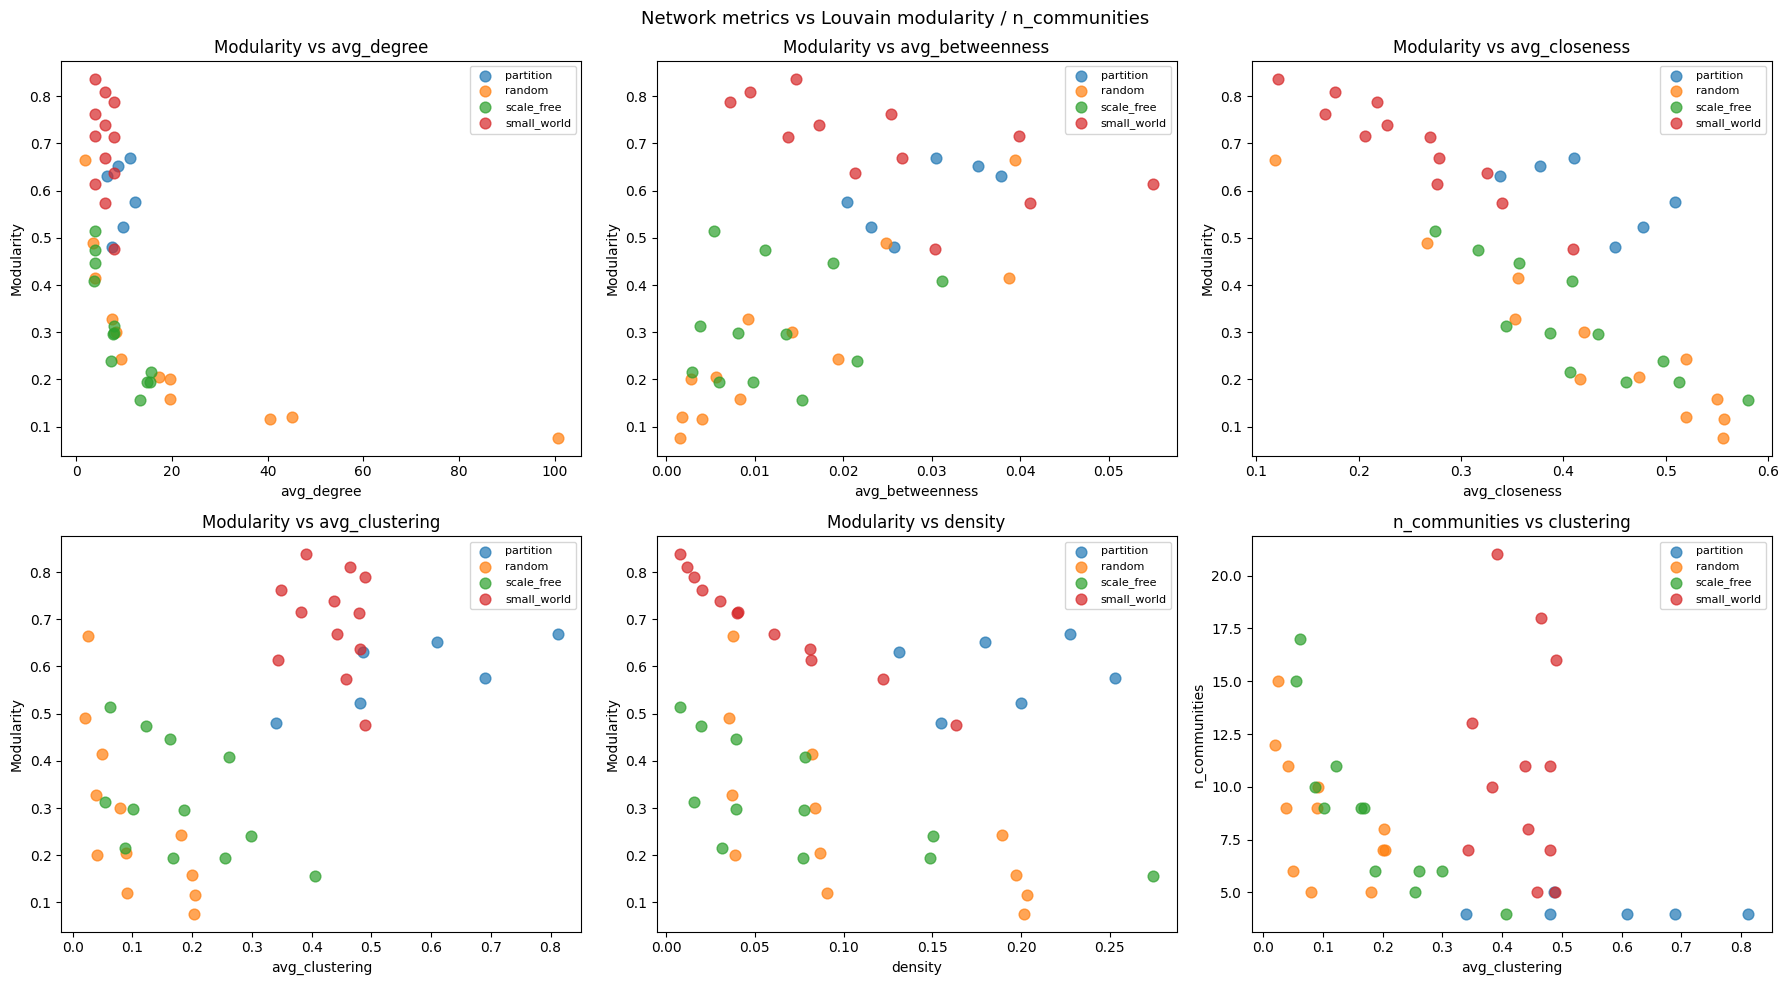

In [56]:
metrics = ["avg_degree", "avg_betweenness", "avg_closeness", "avg_clustering", "density"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    for net_type, group in df.groupby("graph_type"):
        ax.scatter(group[metric], group["modularity"], label=net_type, alpha=0.7, s=60)
    ax.set_xlabel(metric)
    ax.set_ylabel("Modularity")
    ax.set_title(f"Modularity vs {metric}")
    ax.legend(fontsize=8)

ax = axes[5]
for net_type, group in df.groupby("graph_type"):
    ax.scatter(group["avg_clustering"], group["n_communities"], label=net_type, alpha=0.7, s=60)
ax.set_xlabel("avg_clustering")
ax.set_ylabel("n_communities")
ax.set_title("n_communities vs clustering")
ax.legend(fontsize=8)

plt.suptitle("Network metrics vs Louvain modularity / n_communities", fontsize=13)
plt.tight_layout()
plt.show()


In [67]:
df_random = df[df["graph_type"] == "random"].sort_values("modularity", ascending=False)
df_partition = df[df["graph_type"] == "partition"].sort_values("modularity", ascending=False)
df_small_world = df[df["graph_type"] == "small_world"].sort_values("modularity", ascending=False)
df_scale_free = df[df["graph_type"] == "scale_free"].sort_values("modularity", ascending=False)

In [70]:
df_random

,n_nodes,n_edges,density,avg_degree,avg_betweenness,avg_closeness,avg_clustering,modularity,n_communities,graph_type,param
24,50,46,0.037551,1.840,0.039422,0.118650,0.025333,0.663989,15,random,"n=50,p=0.04"
27,100,175,0.035354,3.500,0.024818,0.266208,0.020500,0.489927,12,random,"n=100,p=0.04"
25,50,101,0.082449,4.040,0.038759,0.355266,0.049873,0.414371,6,random,"n=50,p=0.09"
30,200,742,0.037286,7.420,0.009313,0.352906,0.038884,0.328351,9,random,"n=200,p=0.04"
28,100,416,0.084040,8.320,0.014226,0.419890,0.079413,0.299582,5,random,"n=100,p=0.09"
26,50,232,0.189388,9.280,0.019422,0.519977,0.180631,0.242373,5,random,"n=50,p=0.2"
31,200,1731,0.086985,17.310,0.005639,0.473471,0.089354,0.204895,9,random,"n=200,p=0.09"
33,500,4878,0.039102,19.512,0.002827,0.415916,0.040723,0.200987,11,random,"n=500,p=0.04"
29,100,976,0.197172,19.520,0.008359,0.550221,0.200360,0.159063,7,random,"n=100,p=0.2"
34,500,11291,0.090509,45.164,0.001856,0.519698,0.091131,0.120305,10,random,"n=500,p=0.09"


In [71]:
df_partition

,n_nodes,n_edges,density,avg_degree,avg_betweenness,avg_closeness,avg_clustering,modularity,n_communities,graph_type,param
40,50,279,0.227755,11.16,0.030459,0.410035,0.811991,0.669409,4,partition,"pin=0.9,pout=0.01"
38,50,220,0.179592,8.80,0.035255,0.376933,0.609043,0.652304,4,partition,"pin=0.7,pout=0.01"
36,50,161,0.131429,6.44,0.037789,0.337937,0.486429,0.630280,5,partition,"pin=0.5,pout=0.01"
41,50,310,0.253061,12.40,0.020391,0.509376,0.689942,0.575666,4,partition,"pin=0.9,pout=0.05"
39,50,245,0.200000,9.80,0.023197,0.477381,0.480372,0.523324,4,partition,"pin=0.7,pout=0.05"
37,50,190,0.155102,7.60,0.025799,0.450525,0.340162,0.479515,4,partition,"pin=0.5,pout=0.05"


In [72]:
df_scale_free

,n_nodes,n_edges,density,avg_degree,avg_betweenness,avg_closeness,avg_clustering,modularity,n_communities,graph_type,param
9,500,996,0.007984,3.984,0.005410,0.274857,0.061740,0.513891,17,scale_free,"n=500,m=2"
6,200,396,0.019899,3.960,0.011168,0.316469,0.122357,0.474323,11,scale_free,"n=200,m=2"
3,100,196,0.039596,3.920,0.018905,0.356909,0.163388,0.446754,9,scale_free,"n=100,m=2"
0,50,96,0.078367,3.840,0.031224,0.407867,0.260881,0.408366,6,scale_free,"n=50,m=2"
10,500,1984,0.015904,7.936,0.003877,0.343828,0.054124,0.313044,15,scale_free,"n=500,m=4"
7,200,784,0.039397,7.840,0.008130,0.386776,0.101246,0.297736,9,scale_free,"n=200,m=4"
4,100,384,0.077576,7.680,0.013579,0.433963,0.187167,0.296305,6,scale_free,"n=100,m=4"
1,50,184,0.150204,7.360,0.021582,0.497126,0.298815,0.239839,6,scale_free,"n=50,m=4"
11,500,3936,0.031551,15.744,0.002967,0.406166,0.087420,0.215870,10,scale_free,"n=500,m=8"
8,200,1536,0.077186,15.360,0.005976,0.461351,0.168056,0.194489,9,scale_free,"n=200,m=8"


In [73]:
df_small_world

,n_nodes,n_edges,density,avg_degree,avg_betweenness,avg_closeness,avg_clustering,modularity,n_communities,graph_type,param
21,500,1000,0.008016,4.0,0.014741,0.121353,0.390600,0.837438,21,small_world,"n=500,k=4"
22,500,1500,0.012024,6.0,0.009432,0.176640,0.464452,0.809986,18,small_world,"n=500,k=6"
23,500,2000,0.016032,8.0,0.007265,0.217420,0.489875,0.788598,16,small_world,"n=500,k=8"
18,200,400,0.020101,4.0,0.025427,0.167194,0.348833,0.761306,13,small_world,"n=200,k=4"
19,200,600,0.030151,6.0,0.017250,0.227876,0.437917,0.738533,11,small_world,"n=200,k=6"
15,100,200,0.040404,4.0,0.039862,0.205848,0.383000,0.716100,10,small_world,"n=100,k=4"
20,200,800,0.040201,8.0,0.013780,0.269405,0.479754,0.713080,11,small_world,"n=200,k=8"
16,100,300,0.060606,6.0,0.026710,0.278198,0.443024,0.668917,8,small_world,"n=100,k=6"
17,100,400,0.080808,8.0,0.021295,0.325266,0.480135,0.636988,7,small_world,"n=100,k=8"
12,50,100,0.081633,4.0,0.055017,0.276695,0.343333,0.613150,7,small_world,"n=50,k=4"


#### Conclusions

- W przypadku sieci Small World najwyzsze wartości modularności wyrózniały się w grafach o niskiej gęstości i duzej wartości parametry n (przy czym niskiemu parametrowi k- sąsiedzi) - wyzsze modularności oznaczały równiez wysokie wartości liczby róznych społeczności. Im wyzszy wynik tym równiez nizsze wartości avg_closeness

- dla sieci Scale Free wyzsze wartości modularności otrzymano dla grafów rowniez dla grafów z większą liczbą wierzchołków, jednak tutaj większe znaczenie miał parametr m odpowiadający za liczbę przyłączanych krawędzi -> to on miał największe znaczenie i im nizsza wartość tego paraemtru, tym większa wartość współczynnika. 

- w przypadku grafów Partition, wyzsze wartości modularności uzyskiwano poprzez zmniejszenie prawdopodobieństwa krawędzi na zewnątrz (p_out) oraz zwiększane prawdopodobieństwa krawędzi do wewnątrz (p_in), co ułatwia tworzenie społeczności o bardziej zagęszczonych komponentach i mniejszej liczbie połączeń między nimi



## Real world data use-case
The data is a history of internal e-mail communication (`sender, recipient, datetime`) between employees of a mid-sized manufacturing company. Multiple recipients of the same e-mail (`To, CC, BCC`) are represented as separate rows without distinguishing the recipient type. The period covered are nine full months (event dates in local time). The file containing the communication events is named `communication.csv`.

Apart from the communication, information about who in the company reports to whom is attached (`reportsto.csv`). Node #86 is CEO.

### Data preparation

In [ ]:
# !apt install libgraphviz-dev
# !pip install pygraphviz

Load raw events data

In [ ]:
import requests
from pathlib import Path

data_file = Path("../lab2/communication.tab")
if not data_file.exists():
    r = requests.get("https://dataverse.harvard.edu/api/access/datafile/:persistentId?persistentId=doi:10.7910/DVN/6Z3CGX/KWTRDM")
    with open(data_file, "w") as file:
        file.write(r.text.replace('"', ''))

# alternatively download from:
# https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/6Z3CGX#

raw_df = pd.read_table(data_file, sep=';', header=0,  parse_dates=["EventDate"])

Load company hierarchy

In [75]:
data_file = Path("../lab2/reportsto.tab")
if not data_file.exists():
    r = requests.get("https://dataverse.harvard.edu/api/access/datafile/:persistentId?persistentId=doi:10.7910/DVN/6Z3CGX/SMALXX")
    with open(data_file, "w") as file:
        file.write(r.text.replace('"', ''))
# alternatively download from:
# https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/6Z3CGX#

reportsto = pd.read_csv(data_file, sep=";")

Clean dataset

In [76]:
non_employee_accounts = reportsto[reportsto.ReportsToID.apply(lambda x: not x.isnumeric())]
rows_to_remove = raw_df.loc[raw_df["Sender"].isin(non_employee_accounts["ID"]) | raw_df["Recipient"].isin(non_employee_accounts["ID"])]
raw_df = raw_df.drop(rows_to_remove.index)
reportsto = reportsto.drop(non_employee_accounts.index)

Plot company hierarchy

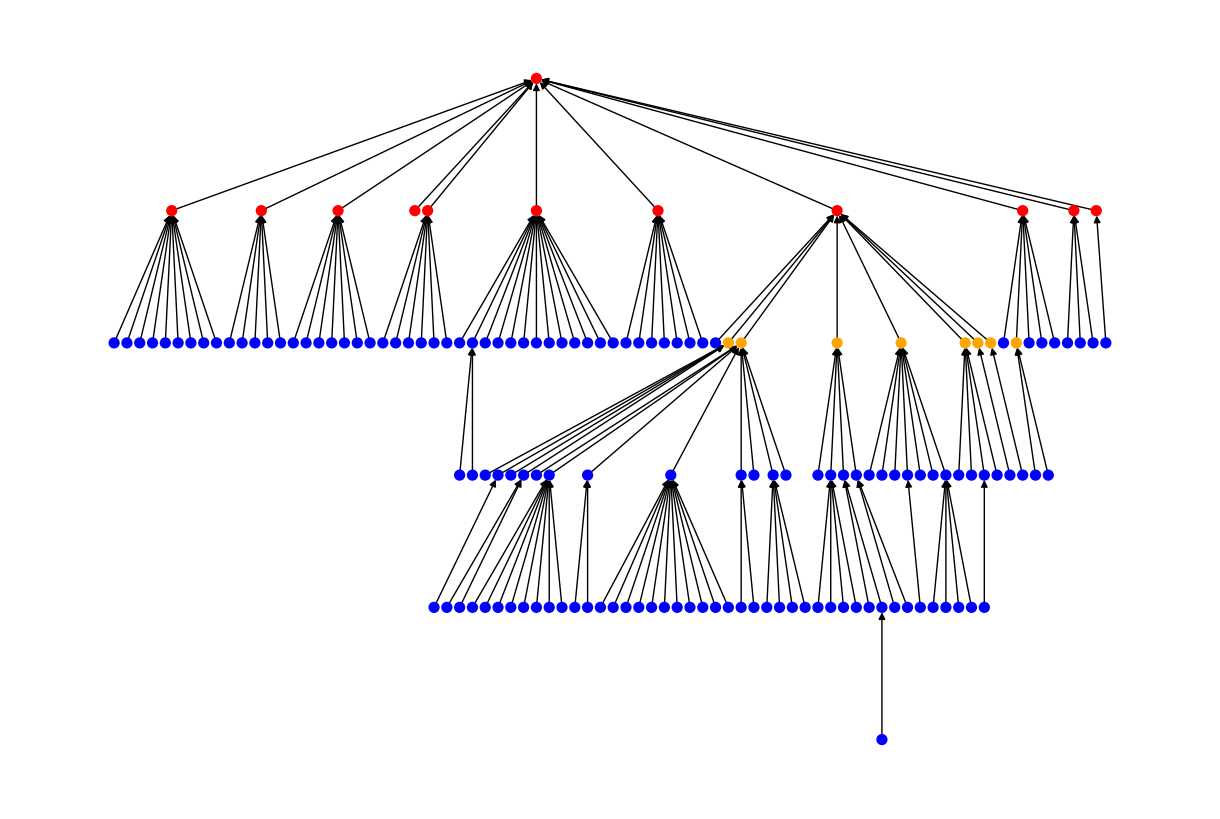

In [77]:
first_management_level = [86, 7, 27, 36, 69, 70, 85, 104, 121, 148, 156, 163]
second_management_level = [76, 90, 136, 137, 143, 152, 47, 162]

H = nx.DiGraph()

for index, row in reportsto.iterrows():
  employee = row['ID']
  supervisor = int(row['ReportsToID'])
  communication_nodes = set(raw_df["Sender"].values + raw_df["Recipient"].values)
  if employee != supervisor and (employee in communication_nodes or supervisor in communication_nodes):
    H.add_edge(employee, supervisor)

color_map = []
for node in H:
  if node in first_management_level:
    color_map.append("red")
  elif node in second_management_level:
    color_map.append("orange")
  else:
    color_map.append("blue")

plt.figure(figsize=(12, 8))
pos_hierarchic = nx.nx_agraph.graphviz_layout(H, prog='dot')
pos_hierarchic = {node: (x,-y) for (node, (x,y)) in pos_hierarchic.items()}
nx.draw(H, pos=pos_hierarchic, with_labels=False, arrows=True, node_size=50, node_color=color_map)

plt.show()

### Task 6
Create a weighted network from the communication data (see Section "Data preparation above").
Check if you can find communities in this real world network. Try different algorithms and approaches.

Can weight of the edges be used in that context? What type of graph representation can be an input to the community detection method you use?

Visualize communities using hirarchy positioning defined in the cell above. For the clarity of visualizations, use only edges from hierarchy company structure.

Analyse and interpret the obtained results, write your conclusions in the cell below. Answer the question: How can this kind of network analysis and exploration be leveraged in the company to improve its functioning?

#### Code

In [79]:
raw_df

,Sender,Recipient,EventDate
0,17,37,2010-01-02 17:40:10
1,17,136,2010-01-02 17:40:10
2,17,62,2010-01-02 17:40:10
3,17,129,2010-01-02 17:40:10
4,17,32,2010-01-02 17:40:10
...,...,...,...
82922,136,143,2010-09-30 17:38:57
82923,136,143,2010-09-30 17:39:12
82924,81,39,2010-09-30 20:18:57
82925,155,136,2010-09-30 22:07:49


In [85]:
G_communication = nx.Graph()
edges = raw_df.groupby(["Sender", "Recipient"], as_index=False).size().rename(columns={"size": "weight"})
for _, row in edges.iterrows():
    s, r, w = int(row["Sender"]), int(row["Recipient"]), row["weight"]
    if s != r:
        if G_communication.has_edge(s, r):
            G_communication[s][r]["weight"] += w
        else:
            G_communication.add_edge(s, r, weight=w)

print(f'nodes: {G_communication.number_of_nodes()}, edges: {G_communication.number_of_edges()}')

nodes: 153, edges: 3190


In [86]:
partition_louvain = nx.community.louvain_communities(G_communication, weight="weight", seed=42)
modularity_louvain = modularity(G_communication, partition_louvain, weight="weight")
print(f"Louvain modularity: {modularity_louvain:.4f}, number of communities: {len(partition_louvain)}")

Louvain modularity: 0.3965, number of communities: 8


In [93]:
partition_louvain_no_weights = nx.community.louvain_communities(G_communication, weight=None, seed=42)
modularity_louvain_no_weights = modularity(G_communication, partition_louvain_no_weights, weight=None)
print(f"Louvain (no weights) modularity: {modularity_louvain_no_weights:.4f}, number of communities: {len(partition_louvain_no_weights)}")

Louvain (no weights) modularity: 0.1253, number of communities: 5


In [89]:
partition_gn = girvan_newman(G_communication)
best_mod_gn, best_pratition_gn = -1, None
for communities in partition_gn:
    partition = list(communities)
    try:
        mod = modularity(G_communication, partition, weight="weight")
    except:
        mod = -1
    if mod > best_mod_gn:
        best_mod_gn = mod
        best_pratition_gn = partition

print(f"Girvan-Newman modularity: {best_mod_gn:.4f}, number of communities: {len(best_pratition_gn)}")

Girvan-Newman modularity: 0.0416, number of communities: 113


In [98]:
partition_gn_no_weights = girvan_newman(G_communication)
best_mod_gn_no_weights, best_pratition_gn_no_weights = -1, None
for communities in partition_gn_no_weights:
    partition = list(communities)
    try:
        mod = modularity(G_communication, partition, weight=None)
    except:
        mod = -1
    if mod > best_mod_gn_no_weights:
        best_mod_gn_no_weights = mod
        best_pratition_gn_no_weights = partition

print(f"Girvan-Newman modularity: {best_mod_gn_no_weights:.4f}, number of communities: {len(best_pratition_gn_no_weights)}")

Girvan-Newman modularity: 0.0002, number of communities: 28


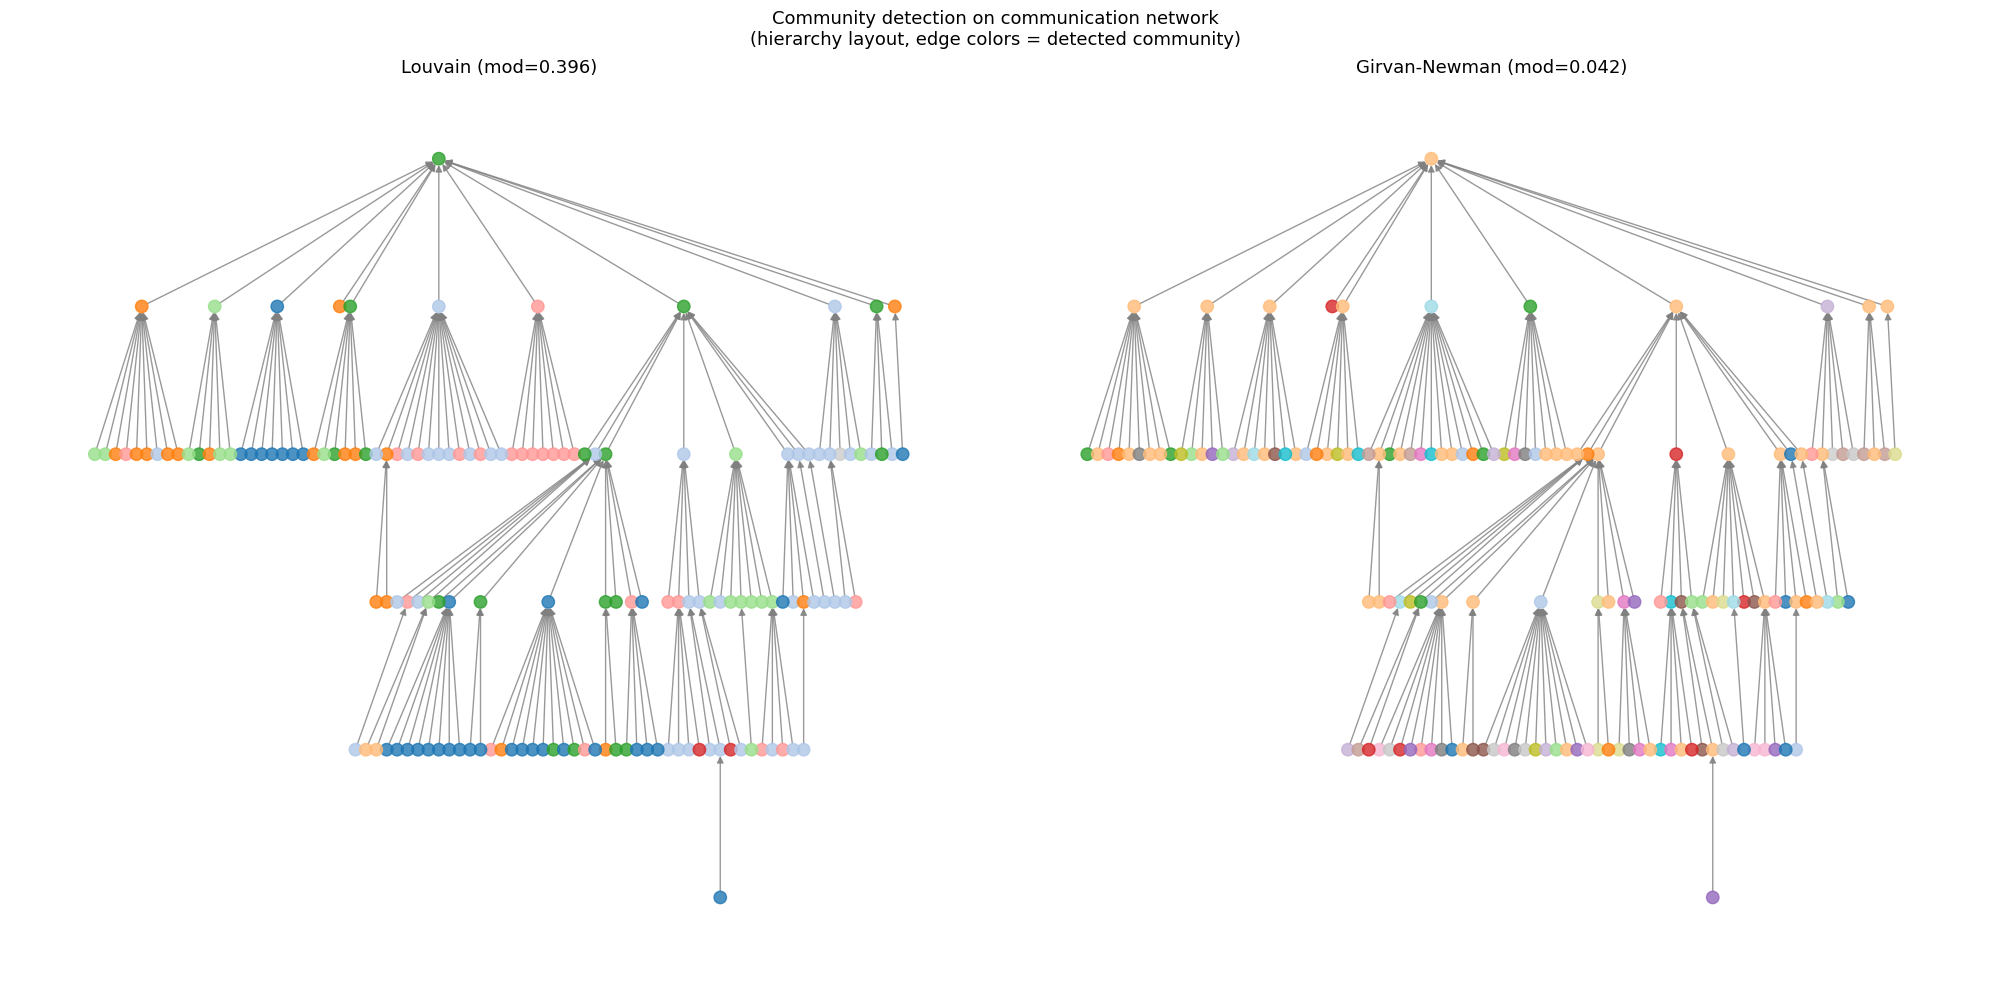

In [90]:
colors_tab = plt.cm.tab20.colors

def get_comm_color(node, partition, colors):
    for i, comm in enumerate(partition):
        if node in comm:
            return colors[i % len(colors)]
    return "#cccccc"

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

for ax, (part, title) in zip(axes, [
    (partition_louvain, f"Louvain (mod={modularity_louvain:.3f})"),
    (best_pratition_gn, f"Girvan-Newman (mod={best_mod_gn:.3f})")
]):
    color_map = [get_comm_color(node, part, colors_tab) for node in H.nodes()]
    nx.draw(H, pos=pos_hierarchic, ax=ax,
            node_color=color_map, with_labels=False,
            arrows=True, node_size=80, edge_color="gray", alpha=0.8)
    ax.set_title(title, fontsize=13)

plt.suptitle("Community detection on communication network\n(hierarchy layout, edge colors = detected community)", fontsize=13)
plt.tight_layout()
plt.show()

In [92]:
for i, comm in enumerate(partition_louvain):
    mgmt1_in = len(comm & set(first_management_level))
    mgmt2_in = len(comm & set(second_management_level))
    print(f"Community {i}: {len(comm)} nodes, "f"top management: {mgmt1_in}, mid management: {mgmt2_in}")

Community 0: 33 nodes, top management: 1, mid management: 0
Community 1: 41 nodes, top management: 2, mid management: 6
Community 2: 18 nodes, top management: 3, mid management: 0
Community 3: 2 nodes, top management: 0, mid management: 0
Community 4: 18 nodes, top management: 4, mid management: 1
Community 5: 17 nodes, top management: 1, mid management: 1
Community 6: 2 nodes, top management: 0, mid management: 0
Community 7: 22 nodes, top management: 1, mid management: 0


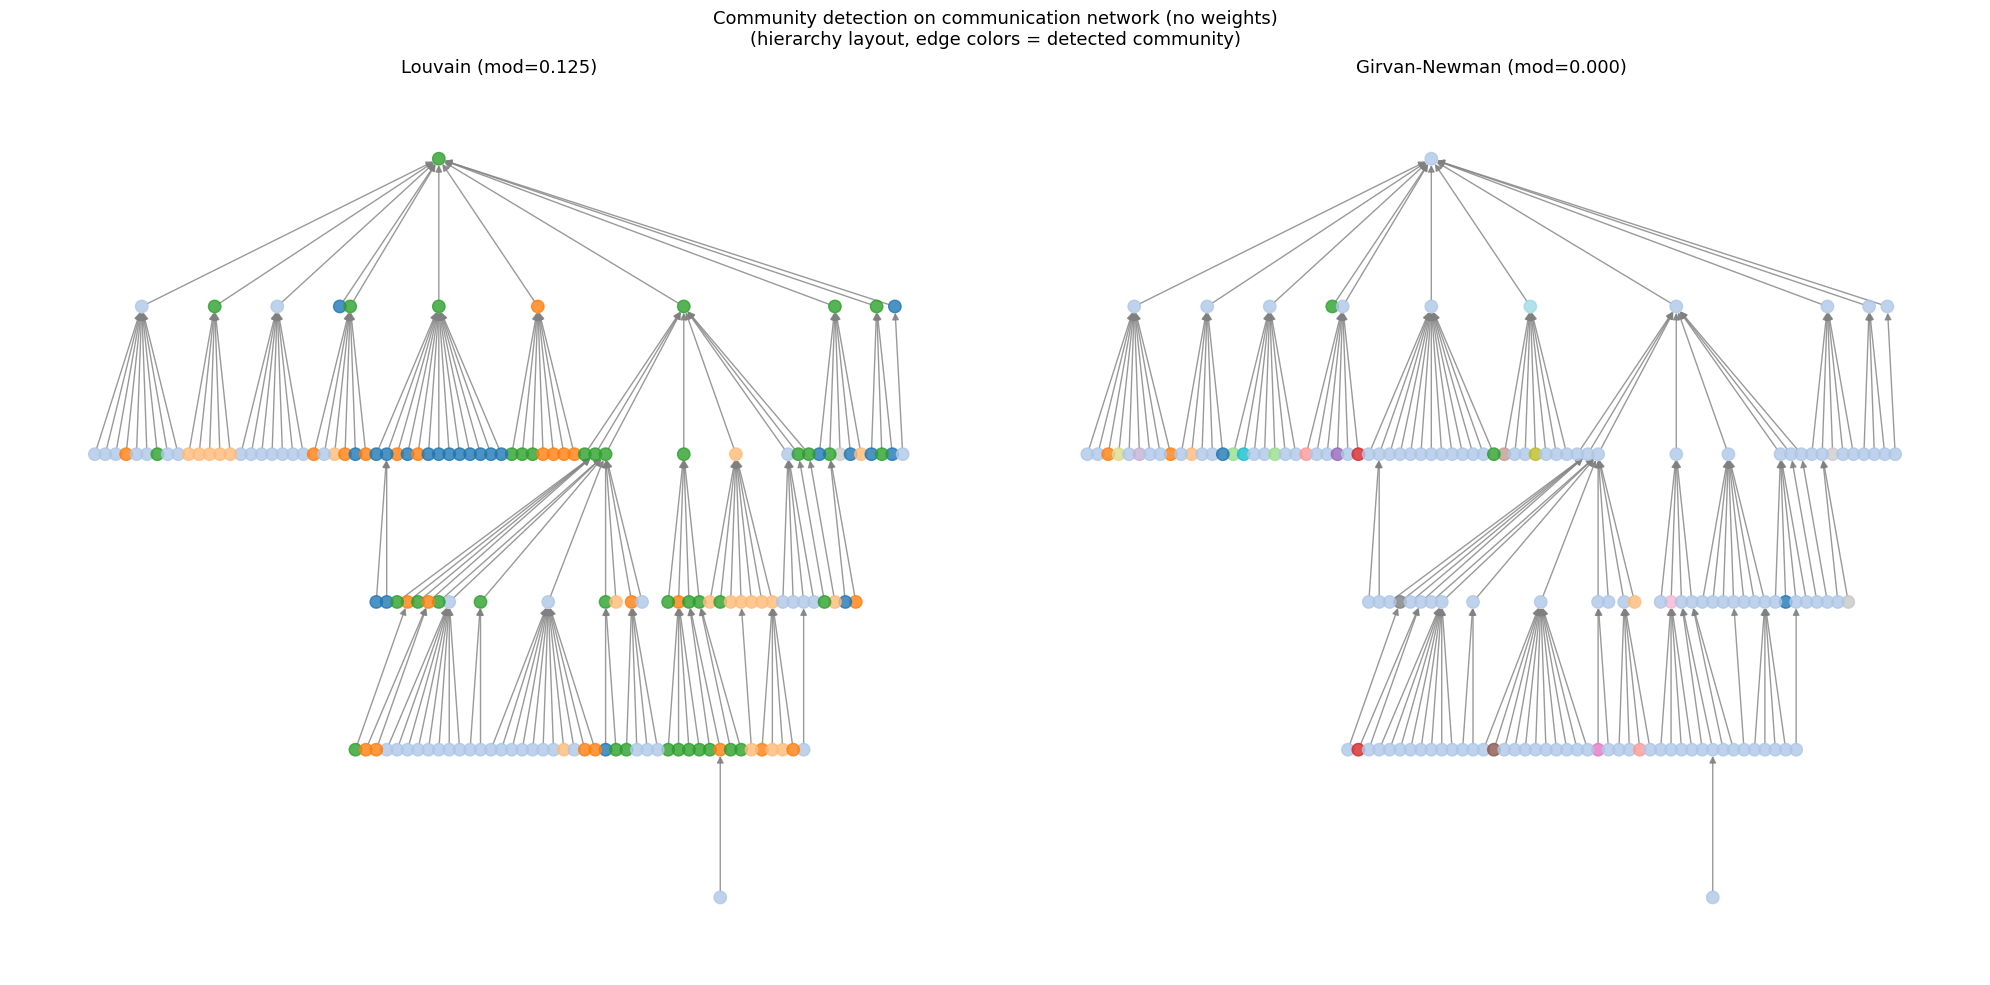

In [99]:
colors_tab = plt.cm.tab20.colors

def get_comm_color(node, partition, colors):
    for i, comm in enumerate(partition):
        if node in comm:
            return colors[i % len(colors)]
    return "#cccccc"

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

for ax, (part, title) in zip(axes, [
    (partition_louvain_no_weights, f"Louvain (mod={modularity_louvain_no_weights:.3f})"),
    (best_pratition_gn_no_weights, f"Girvan-Newman (mod={best_mod_gn_no_weights:.3f})")
]):
    color_map = [get_comm_color(node, part, colors_tab) for node in H.nodes()]
    nx.draw(H, pos=pos_hierarchic, ax=ax,
            node_color=color_map, with_labels=False,
            arrows=True, node_size=80, edge_color="gray", alpha=0.8)
    ax.set_title(title, fontsize=13)

plt.suptitle("Community detection on communication network (no weights)\n(hierarchy layout, edge colors = detected community)", fontsize=13)
plt.tight_layout()
plt.show()

#### Conclusions

Do tego zadania wykorzystano graf nieskierowany (z załozeniem, ze będziemy dzielić na społeczności pracowników, w których dwie osoby w ogóle się ze sobą komunikują - wówczas nieistotne jest kto inicjuje - tylko kto z kim współpracuje). 

W przypadku louvain rozpatrzono dwa przypadki: podział z uwzględnieniem wag oraz nie. Przypadek z uwzględnieniem wag (czyli liczby połączeń) dał wyzszą wartość modularności, czyli lepiej podzielił graf na społeczności. Mozna to zauwazyć równiez na grafie z hierarchią pracowników. W przypadku grafu bez uwzględnienia wag mozna zauwazyć podział na społeczności i w wielu przypadkach pokrywa się z hierarchią na szczeblach pracowniczych, natomiast widoczne są przypaki, gdzie na wyzszym stopniu mamy zupełnie inną społeczność niz "podlegli" mu pracownicy. W przypadku wizualizacji z uwzględnieniem wag, takie przypadki są minimalne i podział na społeczności pokrywa się z podziałem hierarchicznym.

W przypadku algorytmu GN podział wykonywany jest za pomocą funkcji betweenness, poniewaz z tego korzysta standardowy algorytm. Wykonano zatem dwa eksperymenty:
w obydwóch przypadkach podzielono graf według standardowego algorytmu (czyli bez uwzględnienia wag), a następnie w 1 wersji oceniano podział modularnością, która uwzględnia wagi, a w 2 wersji bez. Podobnie jak w przypadku poprzedniego algorytmu, tutaj równiez uwzględnienie wag dało lepsze wyniki modularności. Z tą róznicą, ze algorytm GN daje gorszy podział na społeczności niz ma to miejsce w Louvain. W przypadku uwzględnienia wag w modularności tworzy według mnie za duzo społeczności, bo az 113, a bez uwzględnienia: 28 (ale w dodatku większość pracowników wrzuca do jednej społeczności). Na wykresach hierarchi nie widać za bardzo pokrycia ze społecznościami.

Dzięki uzyciu wag (szczególnie w przypadku algorytmu Louvain) lepiej mozna odzwierciedlać rzeczywiste grupy robocze niz detekcją bez wag. Praktycznie moze nam to pomóc do wykrywania osób łączących zespoły/działy, będacych kluczowymi dla przepływu informacji. Dodatkowo porównania tworzonych społeczności z hierarchią moze ujawniać, czy decyzje/komunikacja płynie zgodnie ze strukturą hierarchi, czy ją omija 